## Experiments

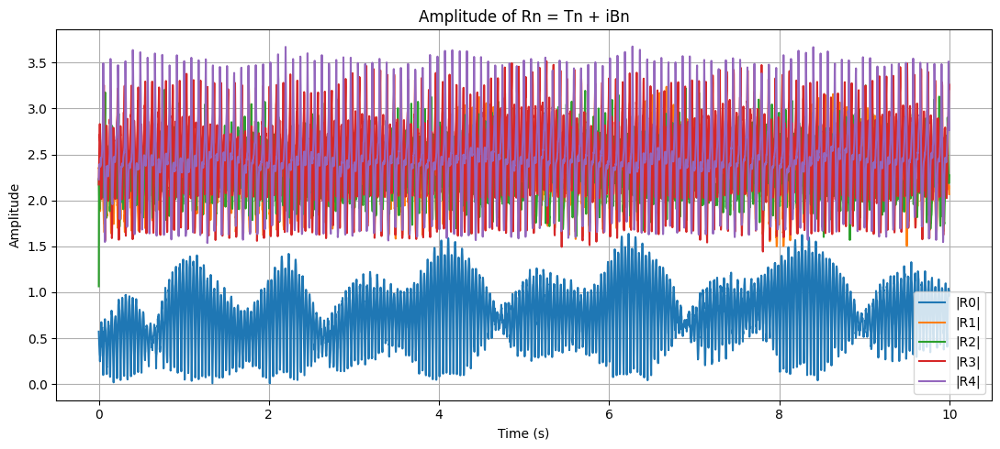

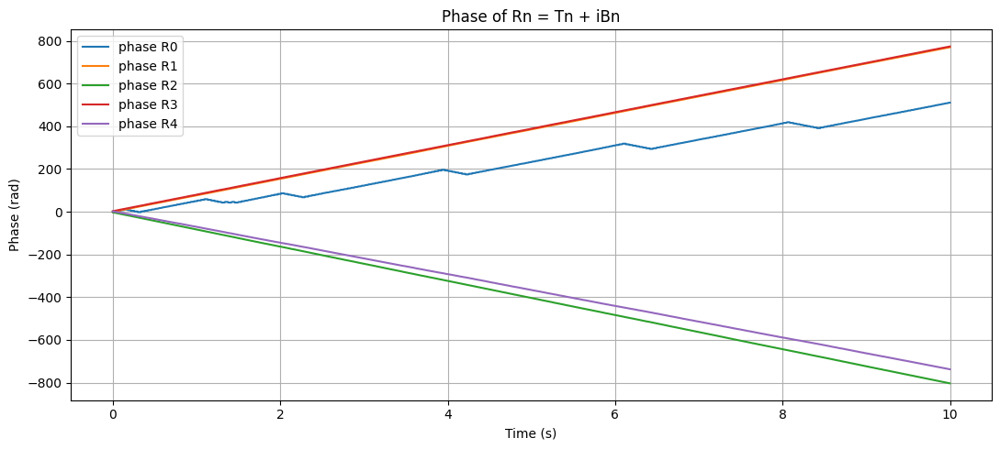

C:\Users\profesor\AppData\Local\Temp\ipykernel_13876\1479116440.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


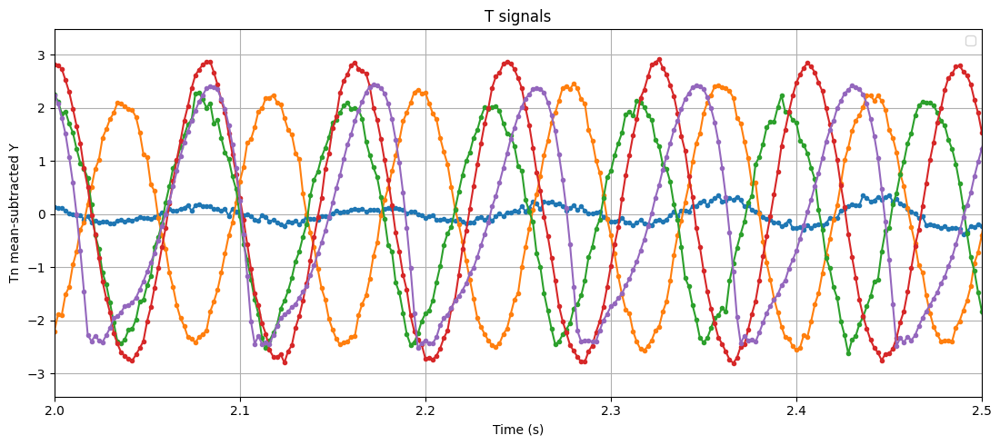

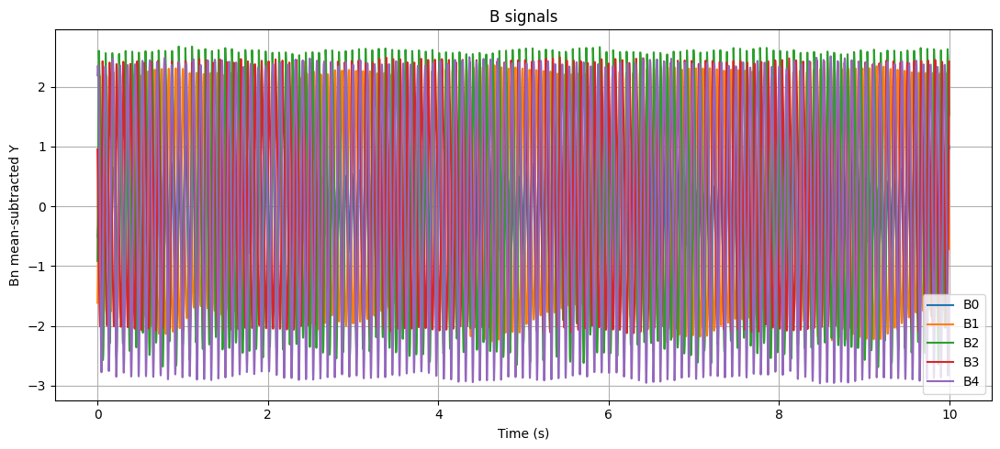

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Settings
# =========================
base = Path(r"15_6_2026\run1")
fs = 500  # sampling frequency in Hz

# =========================
# Function to read Y data
# =========================
def read_y(file_path):
    df = pd.read_csv(
        file_path,
        sep="\t",
        skiprows=8,
        header=None,
        names=["X", "Y", "Z"]
    )

    y = df["Y"].to_numpy()
    y = y - np.mean(y)   # subtract mean
    return y

# =========================
# Read T0-T4 and B0-B4
# =========================
T = {}
B = {}

for n in range(5):   # 0,1,2,3,4
    T[n] = read_y(base / f"T{n}.tsv")
    B[n] = read_y(base / f"B{n}.tsv")

# =========================
# Build complex signals
# Rn = Tn + i Bn
# =========================
R = {}
amp = {}
phase = {}

for n in range(5):
    R[n] = T[n] + 1j * B[n]
    amp[n] = np.abs(R[n])
    phase[n] = np.unwrap(np.angle(R[n]))

# =========================
# Time axis
# =========================
N = len(R[0])
t = np.arange(N) / fs

# =========================
# Plot amplitude
# =========================
plt.figure(figsize=(11, 5))

for n in range(5):
    plt.plot(t, amp[n], label=f"|R{n}|")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Amplitude of Rn = Tn + iBn")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# Plot phase
# =========================
plt.figure(figsize=(11, 5))

for n in range(5):
    plt.plot(t, phase[n], label=f"phase R{n}")

plt.xlabel("Time (s)")
plt.ylabel("Phase (rad)")
plt.title("Phase of Rn = Tn + iBn")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# Optional: plot real/imaginary parts
# =========================
plt.figure(figsize=(11, 5))

for n in range(5):
    plt.plot(t, T[n],'.-')

plt.xlabel("Time (s)")
plt.ylabel("Tn mean-subtracted Y")
plt.title("T signals")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(2, 2.5)  # limit x-axis to first 10 seconds for clarity
plt.show()

plt.figure(figsize=(11, 5))

for n in range(5):
    plt.plot(t, B[n], label=f"B{n}")

plt.xlabel("Time (s)")
plt.ylabel("Bn mean-subtracted Y")
plt.title("B signals")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

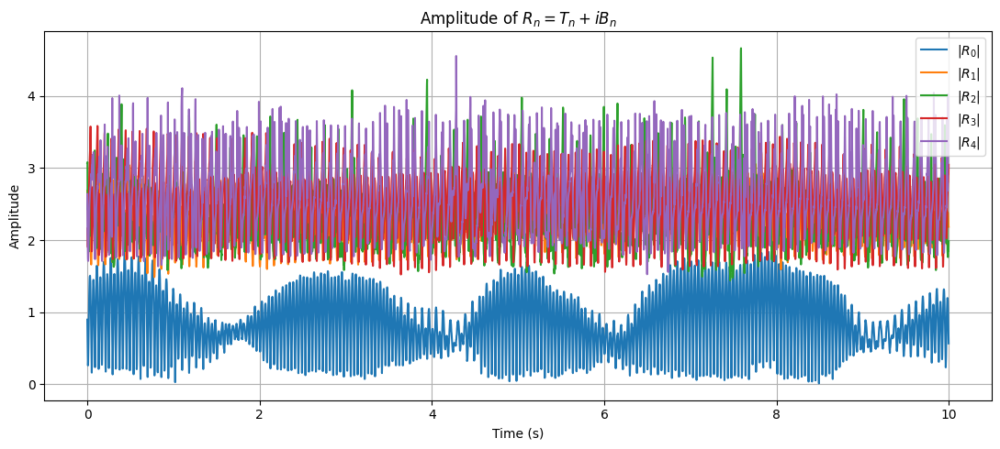

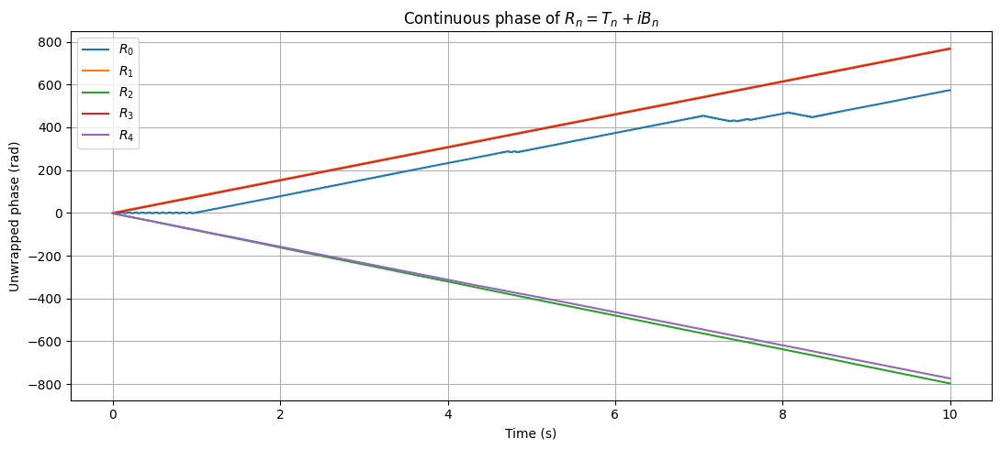

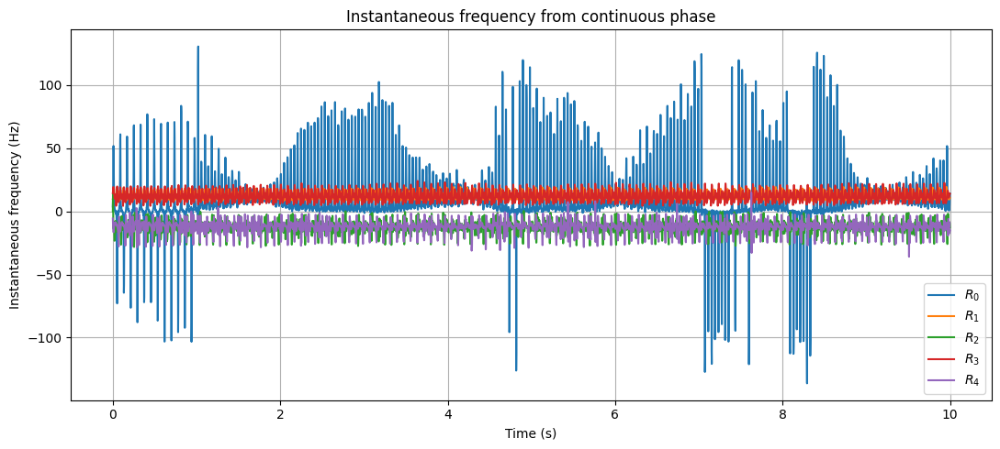

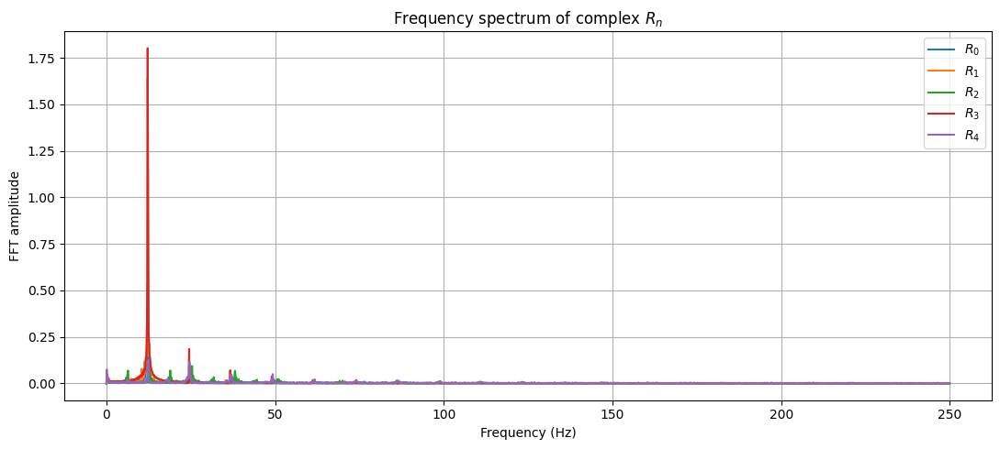

Dominant frequencies from FFT:
R0: 12.2000 Hz
R1: 12.2000 Hz
R2: 25.4000 Hz
R3: 12.2000 Hz
R4: 12.4000 Hz


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Settings
# =========================
base = Path("/Users/rupeshmahore/Documents/Altermagnets/run3")
fs = 500  # Hz
dt = 1 / fs

# =========================
# Read Y data
# =========================
def read_y(file_path):
    df = pd.read_csv(
        file_path,
        sep="\t",
        skiprows=8,
        header=None,
        names=["X", "Y", "Z"]
    )

    y = pd.to_numeric(df["Y"], errors="coerce").to_numpy()
    y = y[~np.isnan(y)]

    # subtract mean from displacement signal
    y = y - np.mean(y)

    return y

# =========================
# Read T0-T4 and B0-B4
# =========================
T = {}
B = {}

for n in range(5):
    T[n] = read_y(base / f"T{n}.tsv")
    B[n] = read_y(base / f"B{n}.tsv")

# =========================
# Make all signals same length
# =========================
N = min(
    min(len(T[n]) for n in range(5)),
    min(len(B[n]) for n in range(5))
)

for n in range(5):
    T[n] = T[n][:N]
    B[n] = B[n][:N]

t = np.arange(N) / fs

# =========================
# Build complex signals
# Rn = Tn + iBn
# =========================
R = {}
amp = {}
phase = {}
freq_inst = {}

for n in range(5):
    R[n] = T[n] + 1j * B[n]

    # Amplitude
    amp[n] = np.abs(R[n])

    # Continuous unwrapped phase
    # Not restricted to [-pi, pi] or [0, 2pi]
    phase[n] = np.unwrap(np.angle(R[n]))

    # Instantaneous frequency in Hz
    freq_inst[n] = np.gradient(phase[n], dt) / (2 * np.pi)

# =========================
# Plot amplitude
# =========================
plt.figure(figsize=(11, 5))

for n in range(5):
    plt.plot(t, amp[n], label=f"$|R_{n}|$")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(r"Amplitude of $R_n = T_n + iB_n$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# Plot continuous phase
# =========================
plt.figure(figsize=(11, 5))

for n in range(5):
    plt.plot(t, phase[n], label=f"$R_{n}$")

plt.xlabel("Time (s)")
plt.ylabel("Unwrapped phase (rad)")
plt.title(r"Continuous phase of $R_n = T_n + iB_n$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# Plot instantaneous frequency
# =========================
plt.figure(figsize=(11, 5))

for n in range(5):
    plt.plot(t, freq_inst[n], label=f"$R_{n}$")

plt.xlabel("Time (s)")
plt.ylabel("Instantaneous frequency (Hz)")
plt.title("Instantaneous frequency from continuous phase")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# FFT spectrum for complex Rn
# =========================
freqs = np.fft.fftfreq(N, d=dt)
positive = freqs >= 0
freqs_pos = freqs[positive]

fft_amp = {}

for n in range(5):
    fft_amp[n] = np.abs(np.fft.fft(R[n])) / N

plt.figure(figsize=(11, 5))

for n in range(5):
    plt.plot(freqs_pos, fft_amp[n][positive], label=f"$R_{n}$")

plt.xlabel("Frequency (Hz)")
plt.ylabel("FFT amplitude")
plt.title(r"Frequency spectrum of complex $R_n$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# Dominant frequency
# =========================
print("Dominant frequencies from FFT:")

for n in range(5):
    fft_pos = fft_amp[n][positive]

    # Ignore zero frequency
    idx = np.argmax(fft_pos[1:]) + 1
    dominant_freq = freqs_pos[idx]

    print(f"R{n}: {dominant_freq:.4f} Hz")

## Altermagnet

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def simulate_and_plot_deterministic(
    name="single_diamond_plots",
    fs=500.0,
    T_total=80.0,
    I=1.0,
    # --- Set explicit parameter arrays for each of the 5 nodes [C, U, L, D, R] ---
    gamma_nodes = [0.1, 0.1, 0.1, 0.1, 0.1],
    k0_nodes    = [1.0,  1.0,  1.0,  1.0,  1.0],
    kc_nodes    = [10.0, 10.0, 10.0, 10.0, 10.0],
    ka_nodes    = [0,  10, 10, 10, 10],
    # --- Set explicit parameter arrays for each of the 4 edges ---
    # Edges order maps to: [(C, U), (C, L), (C, D), (C, R)]
    k_link_edges = [1.0,  2,  1.0,  2]
):
    #outdir = Path(outdir)
    #outdir.mkdir(exist_ok=True)

    dt = 1 / fs
    steps = int(T_total / dt)

    names = ["C", "U", "L", "D", "R"]
    latex_names = [r"R_C", r"R_U", r"R_L", r"R_D", r"R_R"]

    positions = np.array([
        [0.0, 0.0],   # C
        [0.0, 1.0],   # U
        [-1.0, 0.0],  # L
        [0.0, -1.0],  # D
        [1.0, 0.0],   # R
    ])

    sigmas = np.array([0, -1, +1, -1, +1], dtype=float)
    edges = [(0, 1), (0, 2), (0, 3), (0, 4)] # C-U, C-L, C-D, C-R

    # Convert node configurations to strict floating arrays
    gamma_arr = np.array(gamma_nodes, dtype=float)
    k0_arr    = np.array(k0_nodes, dtype=float)
    kc_arr    = np.array(kc_nodes, dtype=float)
    ka_arr    = np.array(ka_nodes, dtype=float)

    # 1. Construct the explicit Link Matrix from the individual edge settings
    k_link_matrix = np.zeros((5, 5))
    for idx, (i, j) in enumerate(edges):
        val = k_link_edges[idx]
        k_link_matrix[i, j] = val
        k_link_matrix[j, i] = val # Symmetric interaction rule

    neighbors = [[] for _ in range(5)]
    for i, j in edges:
        neighbors[i].append(j)
        neighbors[j].append(i)

    # 2. Updated acceleration function matching your custom arrays
    def acceleration(R, V):
        lap = np.zeros_like(R, dtype=complex)
        for p in range(5):
            for q in neighbors[p]:
                # Apply the explicit connection coupling weight
                lap[p] += k_link_matrix[p, q] * (R[p] - R[q])

        return (
            -gamma_arr * V
            -k0_arr * R
            -kc_arr * (np.abs(R) ** 2) * R
            -lap
            + 1j * ka_arr * sigmas * R
        ) / I

    # Seed uniform initialization weights deterministically to eliminate variations across runs
    R = np.array([0.1 + 0.1j] * 5, dtype=complex)
    V = np.array([0.0 + 0.0j] * 5, dtype=complex)

    history_R = np.zeros((steps, 5), dtype=complex)
    t = np.arange(steps) * dt

    # Runge-Kutta 2nd Order (RK2 / Heun's Method) Integration
    for n in range(steps):
        A0 = acceleration(R, V)
        V_half = V + 0.5 * dt * A0
        R_new = R + dt * V_half
        A1 = acceleration(R_new, V_half)
        V_new = V_half + 0.5 * dt * A1

        R, V = R_new, V_new
        history_R[n] = R

    # Post-processing calculations
    amp = np.abs(history_R)
    phase = np.unwrap(np.angle(history_R), axis=0)
    freq_inst = np.gradient(phase, dt, axis=0) / (2 * np.pi)

    N = len(t)
    freqs = np.fft.fftfreq(N, d=dt)
    positive = freqs >= 0
    freqs_pos = freqs[positive]
    fft_amp = np.abs(np.fft.fft(history_R, axis=0)) / N

# # Plot Geometry Network Map
    plt.figure(figsize=(5.5, 5.5))
    for idx, (i, j) in enumerate(edges):
        plt.plot([positions[i, 0], positions[j, 0]], [positions[i, 1], positions[j, 1]], 
                 linewidth=2, label=f"k_link={k_link_edges[idx]}" if idx==0 else "")
    plt.scatter(positions[:, 0], positions[:, 1], s=320, edgecolors="k", zorder=3)
    
    for i, name in enumerate(names):
        # --- NEW CODE: Convert sigmas value to text sign representation ---
        if sigmas[i] > 0:
            sign_str = "(+)"
        elif sigmas[i] < 0:
            sign_str = "(-)"
        else:
            sign_str = "(0)" # For the center node C
            
        # Include the sign_str directly in the first line of the label text
        plt.text(positions[i, 0] + 0.06, positions[i, 1] + 0.06, 
                 f"{name} {sign_str}\nγ={gamma_arr[i]}\nk0={k0_arr[i]}\nka={ka_arr[i]}\nkc={kc_arr[i]}", 
                 fontsize=9, fontweight='semibold')
                 
    plt.axis("equal")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Diamond Geometry Configuration Map")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot Amplitude curves
    plt.figure(figsize=(11, 4))
    for n in range(5):
        plt.plot(t, amp[:, n], label=fr"$|{latex_names[n]}|$")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("Amplitude of Network Complex Signals")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':')
    plt.tight_layout()
    #plt.savefig(outdir / "deterministic_amplitude.png", dpi=220)
    plt.show()

# === Plot Unwrapped continuous phase lines (4 Subplots) ===
    fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharey=False)
    
    # Subplot 1: Center Node
    plt.subplot(1, 4, 1)
    plt.plot(t, phase[:, 0], color='#7f7f7f', linewidth=2, label=fr"${latex_names[0]}$")
    plt.title("Center Node")
    plt.ylabel("Unwrapped Phase (rad)")
    plt.xlabel("Time (s)")
    plt.grid(True, linestyle=':')
    plt.legend(loc='upper left')

    # Subplot 2: Vertical Axis (U and D)
    plt.subplot(1, 4, 2) #relative phase difference between U and D
    plt.plot(t, phase[:, 1]- phase[:, 3], color='#1f77b4', label=fr"${latex_names[1]}-{latex_names[3]}$") 
    plt.title("Relative Phase Difference (U & D)")
    plt.xlabel("Time (s)")
    plt.grid(True, linestyle=':')
    plt.legend(loc='upper left')

    # Subplot 3: Horizontal Axis (L and R)
    plt.subplot(1, 4, 3) # relative phase difference between L and R
    plt.plot(t, phase[:, 2] - phase[:, 4], color='#d62728', label=fr"${latex_names[2]}-{latex_names[4]}$") 
    plt.title("Relative Phase Difference (L & R)")
    plt.xlabel("Time (s)")
    plt.grid(True, linestyle=':')
    plt.legend(loc='upper left')

    #subplot 4
    plt.subplot(1, 4, 4)
    for n in range(5):
        plt.plot(t, phase[:, n], label=fr"${latex_names[n]}$")
    plt.title("All Nodes Continuous Phase")
    plt.xlabel("Time (s)")
    plt.grid(True, linestyle=':')
    plt.legend(loc='upper left')

    # Global title adjustment and clean save
    plt.suptitle("Continuous Unwrapped Phase Tracks by Diamond Axis", fontsize=13, fontweight='bold', y=0.98)
    plt.tight_layout()
    #plt.savefig(outdir / "deterministic_unwrapped_phase.png", dpi=220)
    plt.show()

    # Plot Instantaneous Frequency lines
    plt.figure(figsize=(11, 4))
    for n in range(5):
        plt.plot(t, freq_inst[:, n], label=fr"${latex_names[n]}$")
    plt.xlabel("Time (s)")
    plt.ylabel("Instantaneous Frequency (Hz)")
    plt.title("Instantaneous Frequency Profiles")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':')
    plt.tight_layout()
    plt.savefig(f"{name}.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    # Track Dominant Frequencies via FFT peaks
    dominant = {}
    for n in range(5):
        fft_pos = fft_amp[positive, n]
        idx = np.argmax(fft_pos[1:]) + 1
        dominant[names[n]] = freqs_pos[idx]

    return dominant

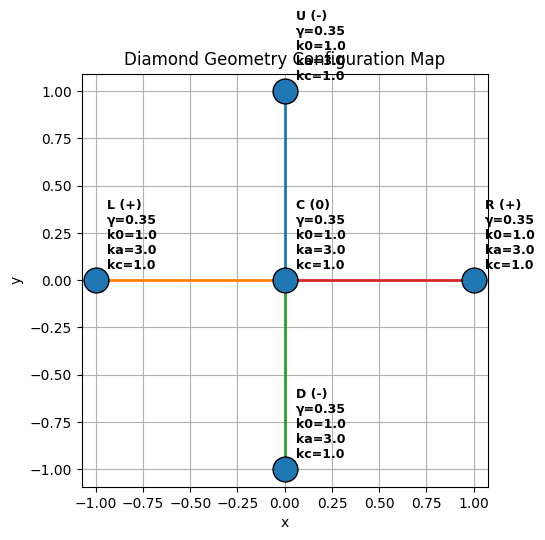

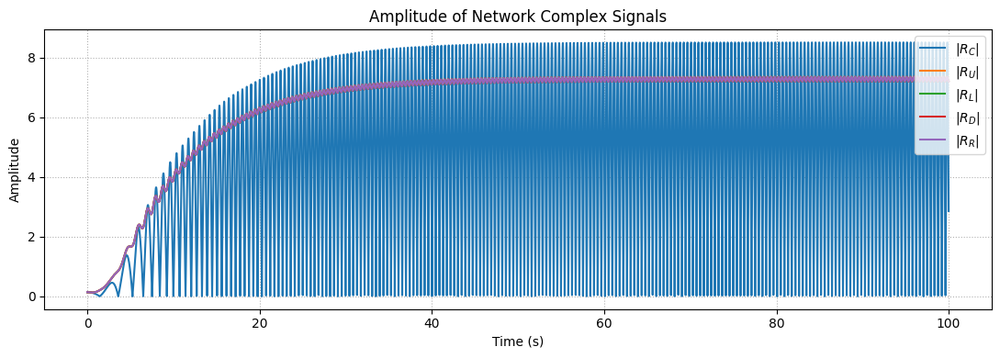

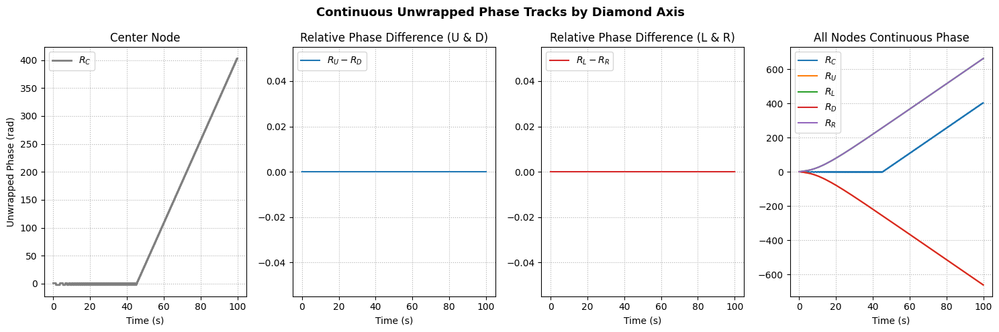

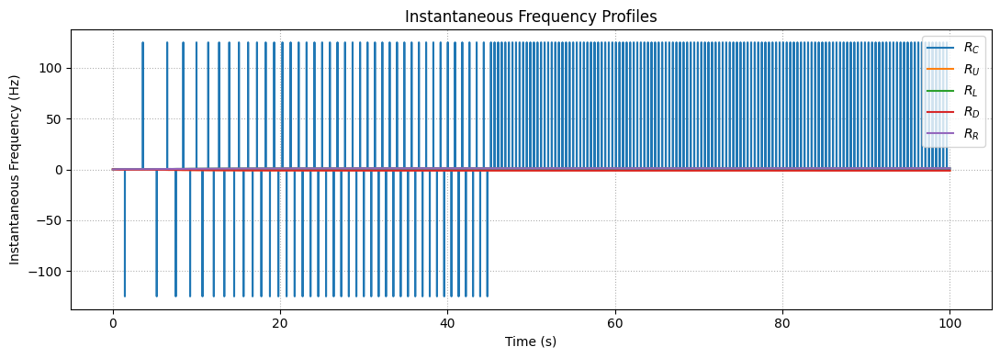


--- Dominant Oscillator Frequencies ---
Node C: 1.1700 Hz
Node U: 1.1700 Hz
Node L: 1.1700 Hz
Node D: 1.1700 Hz
Node R: 1.1700 Hz


In [22]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [0.35, 0.35, 0.35, 0.35, 0.35]  # Higher dampening on Node U
    my_k0    = [1.0,  1.0,  1.0,  1.0,  1.0]  # Stiffer onsite spring on Node L
    my_kc    = [1.0, 1.0, 1.0, 1.0, 1.0] 
    ka_v = 3
    my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    #my_ka    =  [0, 4, 4, 4, 4]
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [1.0, 1.0, 1.0, 1.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=100.0 # Shortened simulation length for quicker visualization testing
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

In [ ]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [0.35, 0.35, 0.35, 0.35, 0.35]  # Higher dampening on Node U
    my_k0    = [1.0,  1.0,  1.0,  1.0,  1.0]  # Stiffer onsite spring on Node L
    my_kc    = [1.0, 1.0, 1.0, 1.0, 1.0] 
    ka_v = 3
    my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    #my_ka    =  [0, 4, 4, 4, 4]
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [1.0, 1.0, 1.0, 1.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=100.0 # Shortened simulation length for quicker visualization testing
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

## Ferromagnet: same chirality

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os 

def simulate_and_plot_deterministic(
    name_file="single_diamond_plots",
    fs=500.0,
    T_total=100.0,
    I=1.0,
    # --- Set explicit parameter arrays for each of the 5 nodes [C, U, L, D, R] ---
    gamma_nodes = [0.1, 0.1, 0.1, 0.1, 0.1],
    k0_nodes    = [1.0,  1.0,  1.0,  1.0,  1.0],
    kc_nodes    = [10.0, 10.0, 10.0, 10.0, 10.0],
    ka_nodes    = [0,  10, 10, 10, 10],
    # --- Set explicit parameter arrays for each of the 4 edges ---
    # Edges order maps to: [(C, U), (C, L), (C, D), (C, R)]
    k_link_edges = [1.0,  2,  1.0,  2],
    sigmas = np.array([0, +1, +1, +1, +1], dtype=float)
):
    outdir = outdir = Path(r"c:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code")
    outdir.mkdir(parents=True, exist_ok=True)
    print(">>> SAVING PLOTS TO THIS FOLDER:", outdir)

    dt = 1 / fs
    steps = int(T_total / dt)

    names = ["C", "U", "L", "D", "R"]
    latex_names = [r"R_C", r"R_U", r"R_L", r"R_D", r"R_R"]

    positions = np.array([
        [0.0, 0.0],   # C
        [0.0, 1.0],   # U
        [-1.0, 0.0],  # L
        [0.0, -1.0],  # D
        [1.0, 0.0],   # R
    ])
    edges = [(0, 1), (0, 2), (0, 3), (0, 4)] # C-U, C-L, C-D, C-R

    # Convert node configurations to strict floating arrays
    gamma_arr = np.array(gamma_nodes, dtype=float)
    k0_arr    = np.array(k0_nodes, dtype=float)
    kc_arr    = np.array(kc_nodes, dtype=float)
    ka_arr    = np.array(ka_nodes, dtype=float)

    # 1. Construct the explicit Link Matrix from the individual edge settings
    k_link_matrix = np.zeros((5, 5))
    for idx, (i, j) in enumerate(edges):
        val = k_link_edges[idx]
        k_link_matrix[i, j] = val
        k_link_matrix[j, i] = val # Symmetric interaction rule

    neighbors = [[] for _ in range(5)]
    for i, j in edges:
        neighbors[i].append(j)
        neighbors[j].append(i)

    # 2. Updated acceleration function matching your custom arrays
    def acceleration(R, V):
        lap = np.zeros_like(R, dtype=complex)
        for p in range(5):
            for q in neighbors[p]:
                # Apply the explicit connection coupling weight
                lap[p] += k_link_matrix[p, q] * (R[p] - R[q])

        return (
            -gamma_arr * V
            -k0_arr * R
            -kc_arr * (np.abs(R) ** 2) * R
            -lap
            + 1j * ka_arr * sigmas * R
        ) / I

    # Seed uniform initialization weights deterministically to eliminate variations across runs
    R = np.array([0.1 + 0.1j] * 5, dtype=complex)
    V = np.array([0.0 + 0.0j] * 5, dtype=complex)

    history_R = np.zeros((steps, 5), dtype=complex)
    t = np.arange(steps) * dt

    # Runge-Kutta 2nd Order (RK2 / Heun's Method) Integration
    for n in range(steps):
        A0 = acceleration(R, V)
        V_half = V + 0.5 * dt * A0
        R_new = R + dt * V_half
        A1 = acceleration(R_new, V_half)
        V_new = V_half + 0.5 * dt * A1

        R, V = R_new, V_new
        history_R[n] = R

    # Post-processing calculations
    amp = np.abs(history_R)
    phase = np.unwrap(np.angle(history_R), axis=0)
    freq_inst = np.gradient(phase, dt, axis=0) / (2 * np.pi)

    N = len(t)
    freqs = np.fft.fftfreq(N, d=dt)
    positive = freqs >= 0
    freqs_pos = freqs[positive]
    fft_amp = np.abs(np.fft.fft(history_R, axis=0)) / N

# # Plot Geometry Network Map
    plt.figure(figsize=(5.5, 5.5))
    for idx, (i, j) in enumerate(edges):
        plt.plot([positions[i, 0], positions[j, 0]], [positions[i, 1], positions[j, 1]], 
                 linewidth=2, label=f"k_link={k_link_edges[idx]}" if idx==0 else "")
    plt.scatter(positions[:, 0], positions[:, 1], s=320, edgecolors="k", zorder=3)
    
    for i, name in enumerate(names):
        # --- NEW CODE: Convert sigmas value to text sign representation ---
        if sigmas[i] > 0:
            sign_str = "(+)"
        elif sigmas[i] < 0:
            sign_str = "(-)"
        else:
            sign_str = "(0)" # For the center node C
            
        # Include the sign_str directly in the first line of the label text
        plt.text(positions[i, 0] + 0.06, positions[i, 1] + 0.06, 
                 f"{name} {sign_str}\nγ={gamma_arr[i]}\nk0={k0_arr[i]}\nka={ka_arr[i]}\nkc={kc_arr[i]}", 
                 fontsize=9, fontweight='semibold')
                 
    plt.axis("equal")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Diamond Geometry Configuration Map")
    plt.grid(True)
    plt.tight_layout()
    #plt.savefig(outdir / "deterministic_geometry.png", dpi=220)
    plt.show()

    # Plot Amplitude curves
    plt.figure(figsize=(11, 4))
    for n in range(5):
        plt.plot(t, amp[:, n], label=fr"$|{latex_names[n]}|$")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("Amplitude of Network Complex Signals")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':')
    plt.tight_layout()
    #plt.savefig(outdir / "deterministic_amplitude.png", dpi=220)
    plt.show()

# === Plot Unwrapped continuous phase lines (4 Subplots) ===
    fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharey=False)
    
    # Subplot 1: Center Node
    plt.subplot(1, 4, 1)
    plt.plot(t, phase[:, 0], color='#7f7f7f', linewidth=2, label=fr"${latex_names[0]}$")
    plt.title("Center Node")
    plt.ylabel("Unwrapped Phase (rad)")
    plt.xlabel("Time (s)")
    plt.grid(True, linestyle=':')
    plt.legend(loc='upper left')

    # Subplot 2: Vertical Axis (U and D)
    plt.subplot(1, 4, 2) #relative phase difference between U and D
    plt.plot(t, phase[:, 1]- phase[:, 3], color='#1f77b4', label=fr"${latex_names[1]}-{latex_names[3]}$") 
    plt.title("Relative Phase Difference (U & D)")
    plt.xlabel("Time (s)")
    plt.grid(True, linestyle=':')
    plt.legend(loc='upper left')

    # Subplot 3: Horizontal Axis (L and R)
    plt.subplot(1, 4, 3) # relative phase difference between L and R
    plt.plot(t, phase[:, 2] - phase[:, 4], color='#d62728', label=fr"${latex_names[2]}-{latex_names[4]}$") 
    plt.title("Relative Phase Difference (L & R)")
    plt.xlabel("Time (s)")
    plt.grid(True, linestyle=':')
    plt.legend(loc='upper left')

    #subplot 4
    plt.subplot(1, 4, 4)
    for n in range(5):
        plt.plot(t, phase[:, n], label=fr"${latex_names[n]}$")
    plt.title("All Nodes Continuous Phase") 
    plt.xlabel("Time (s)")
    plt.grid(True, linestyle=':')
    plt.legend(loc='upper left')

    # Global title adjustment and clean save
    plt.suptitle("Continuous Unwrapped Phase Tracks by Diamond Axis", fontsize=13, fontweight='bold', y=0.98)
    plt.tight_layout()
    #plt.savefig(outdir / "deterministic_unwrapped_phase.png", dpi=220)
    plt.show()

    # =========================
    # Plot continuous phase
    # =========================
    fig_phase = plt.figure(figsize=(8, 5))

    for n in range(5):
        #plt.plot(t, phase[:, n]-phase[:, 4], label=f"${latex_names[n]}-{latex_names[4]}$")  # phase difference
        plt.plot(t, phase[:, n], label=fr"${latex_names[n]}$")    # absolute phase

    plt.xlabel("Time (s)", fontsize=20)
    plt.ylabel("Phase (rad)", fontsize=20)
    #plt.title(r"Continuous phase difference of $R_n = T_n + iB_n$")
    plt.legend(fontsize=20)
    plt.grid(True)
    plt.tick_params(axis='both', which='major', labelsize=18)
    plt.tight_layout()
    fig_phase.savefig(outdir / f"{name_file}_phase.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    # Plot Instantaneous Frequency lines
    fig_freq = plt.figure(figsize=(8, 5))
    for n in range(5):
        plt.plot(t, freq_inst[:, n], label=fr"${latex_names[n]}$")
    plt.xlabel("Time (s)", fontsize=20)
    plt.ylabel("Frequency (Hz)", fontsize=20)
    #plt.title("Instantaneous Frequency Profiles", fontsize=20)
    plt.legend(loc='upper right', fontsize=20)
    plt.grid(True, linestyle=':')
    plt.tick_params(axis='both', which='major', labelsize=18)
    plt.tight_layout()
    #fig_freq.savefig(outdir / f"{name_file}_freq.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    print("Final unwrapped phase values at last time step:")
    for n in range(5):
        print(f"Node {latex_names[n]}: {phase[-1, n]:.4f} rad")

    # Track Dominant Frequencies via FFT peaks
    dominant = {}
    for n in range(5):
        fft_pos = fft_amp[positive, n]
        idx = np.argmax(fft_pos[1:]) + 1
        dominant[names[n]] = freqs_pos[idx]
    print(f"All plots saved successfully in: {outdir.resolve()}")
    return dominant

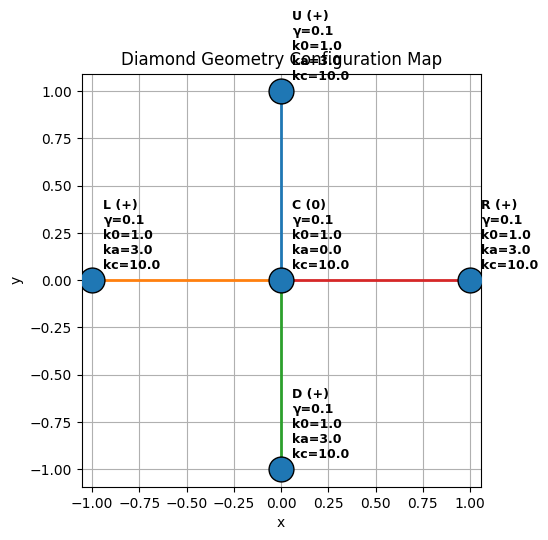

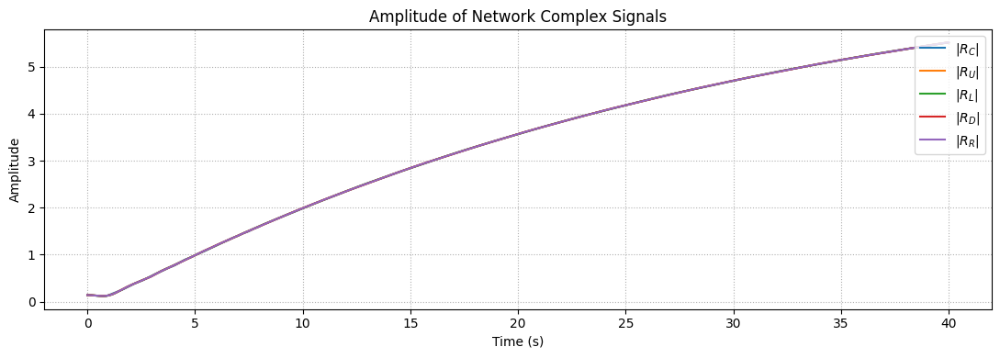

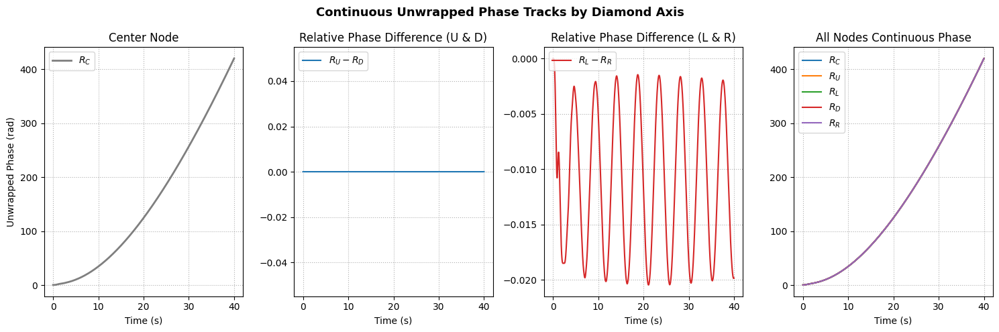

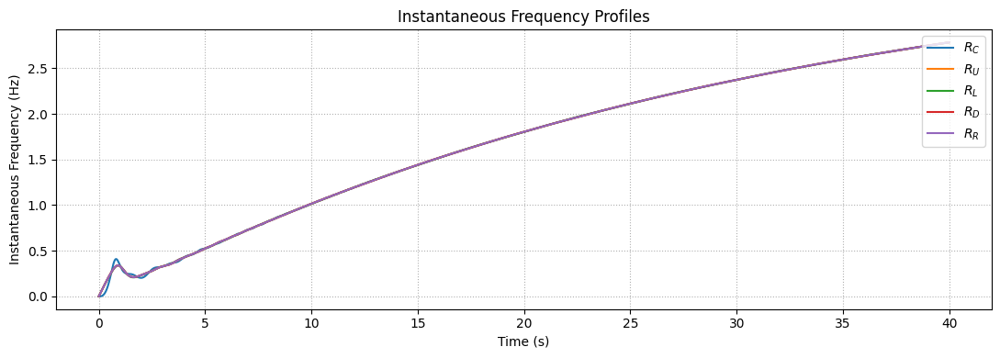


--- Dominant Oscillator Frequencies ---
Node C: 2.6250 Hz
Node U: 2.6250 Hz
Node L: 2.6250 Hz
Node D: 2.6250 Hz
Node R: 2.6250 Hz


In [70]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [0.1, 0.1, 0.1, 0.1, 0.1]  # Higher dampening on Node U
    my_k0    = [1.0,  1.0,  1.0,  1.0,  1.0]  # Stiffer onsite spring on Node L
    my_kc    = [10.0, 10.0, 10.0, 10.0, 10.0] 
    #ka_v = 4
    #my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    my_ka    =  [0, 3, 3, 3, 3]
    sigmas = np.array([0, +1, +1, +1, +1], dtype=float)  # ferromagnet
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [5.0, 5.5, 5.0, 5.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=40.0, # Shortened simulation length for quicker visualization testing
        sigmas = sigmas
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

For this ferromagnet, they all synchronize.

Let's add some disorder:

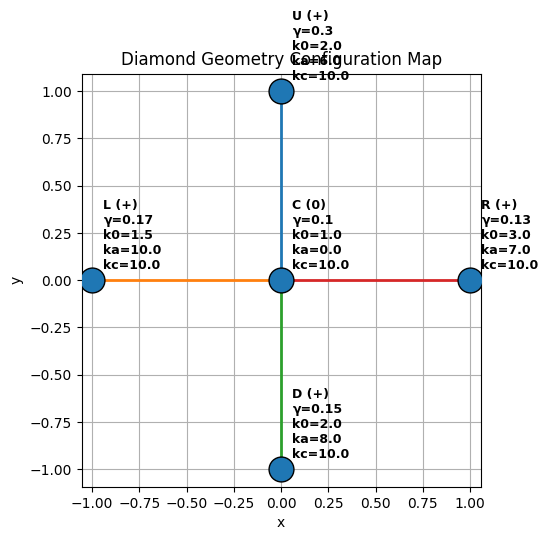

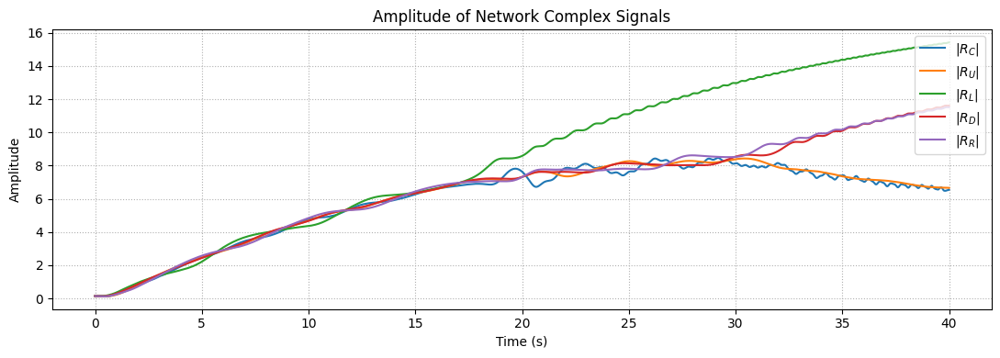

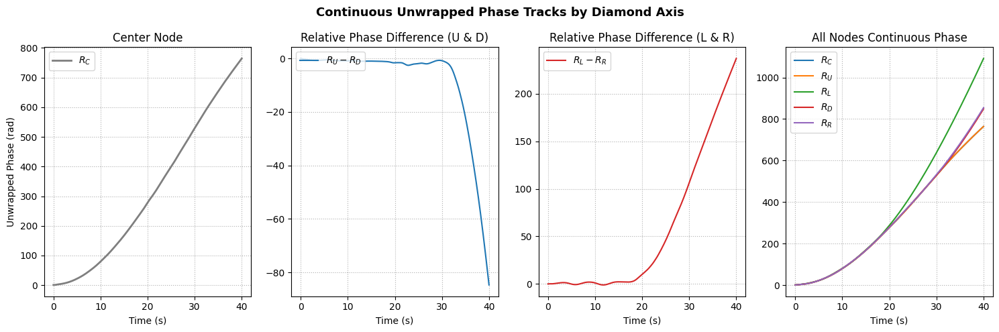

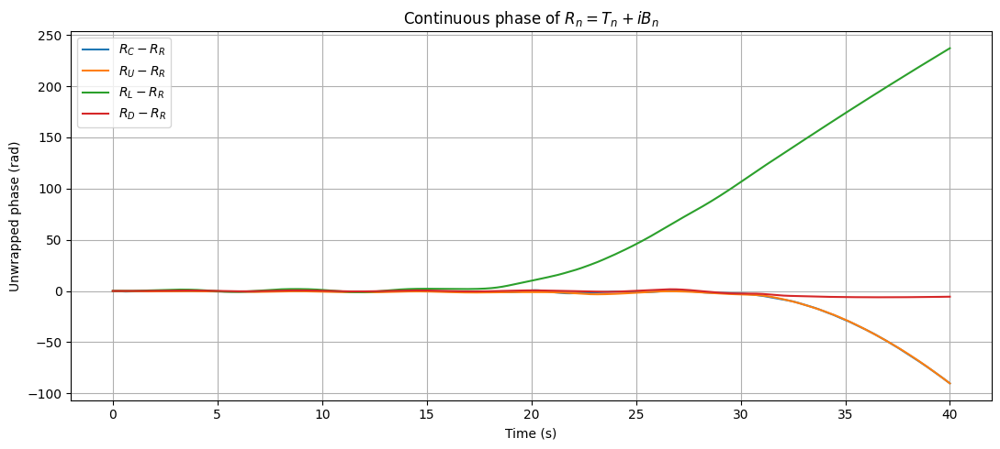

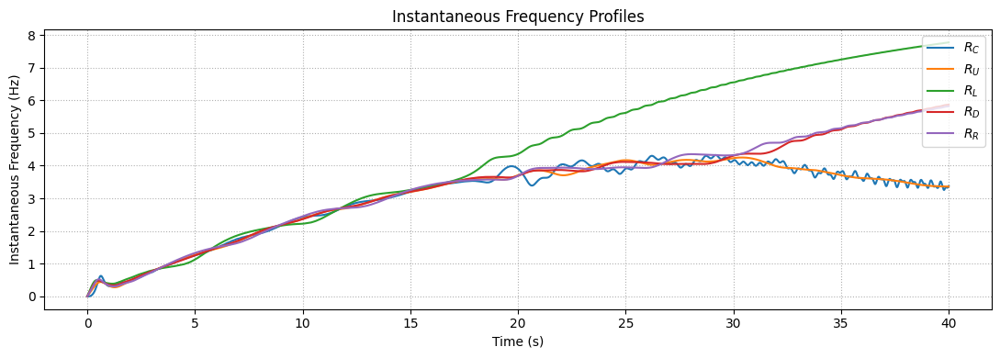

Final unwrapped phase values at last time step:
Node R_C: 764.2900 rad
Node R_U: 764.3381 rad
Node R_L: 1091.7039 rad
Node R_D: 849.0060 rad
Node R_R: 854.5584 rad

--- Dominant Oscillator Frequencies ---
Node C: 4.0750 Hz
Node U: 4.1250 Hz
Node L: 7.5250 Hz
Node D: 4.0750 Hz
Node R: 3.9250 Hz


In [93]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [0.1, 0.3, 0.17, 0.15, 0.13]  # Higher dampening on Node U
    my_k0    = [1.0,  2.0,  1.5,  2.0,  3.0]  # Stiffer onsite spring on Node L
    my_kc    = [10.0, 10.0, 10.0, 10.0, 10.0] 
    #ka_v = 4
    #my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    my_ka    =  [0, 6, 10, 8, 7]
    sigmas = np.array([0, +1, +1, +1, +1], dtype=float)  # ferromagnet
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [5.5, 6.0, 5.0, 4.5]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=40.0, # Shortened simulation length for quicker visualization testing
        sigmas = sigmas
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

C:\Users\profesor\AppData\Local\Temp\ipykernel_23032\2930721697.py:67: RuntimeWarning: overflow encountered in square
  -kc_arr * (np.abs(R) ** 2) * R
C:\Users\profesor\AppData\Local\Temp\ipykernel_23032\2930721697.py:64: RuntimeWarning: invalid value encountered in divide
  return (


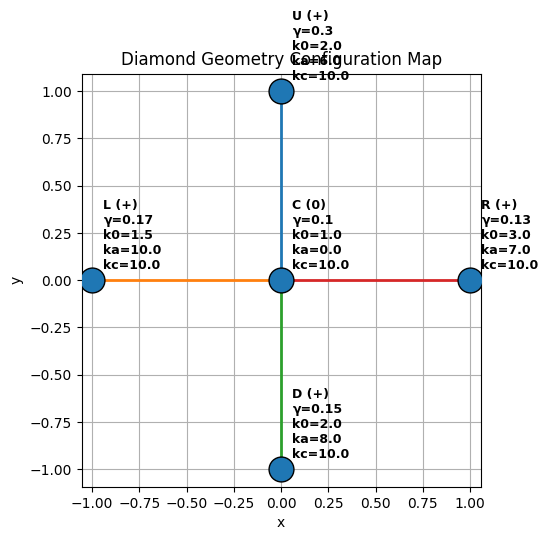

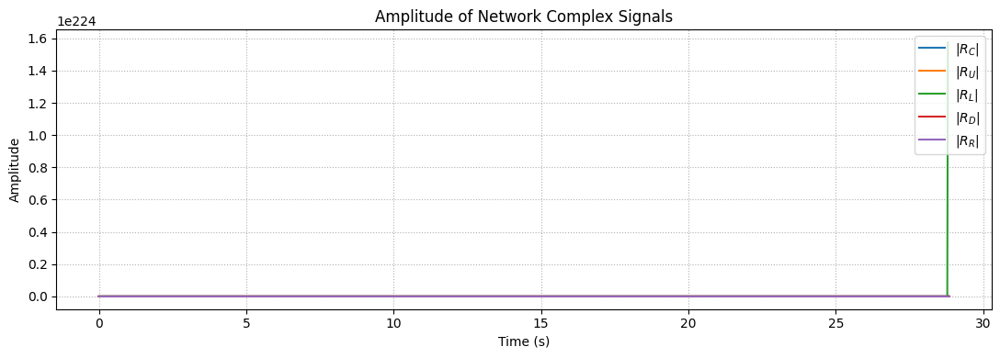

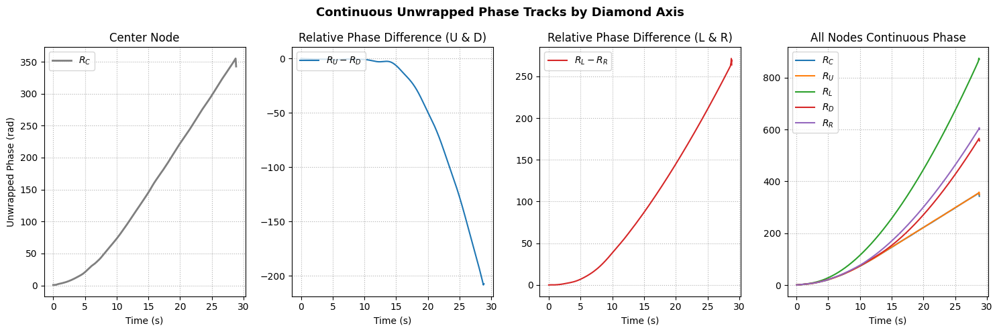

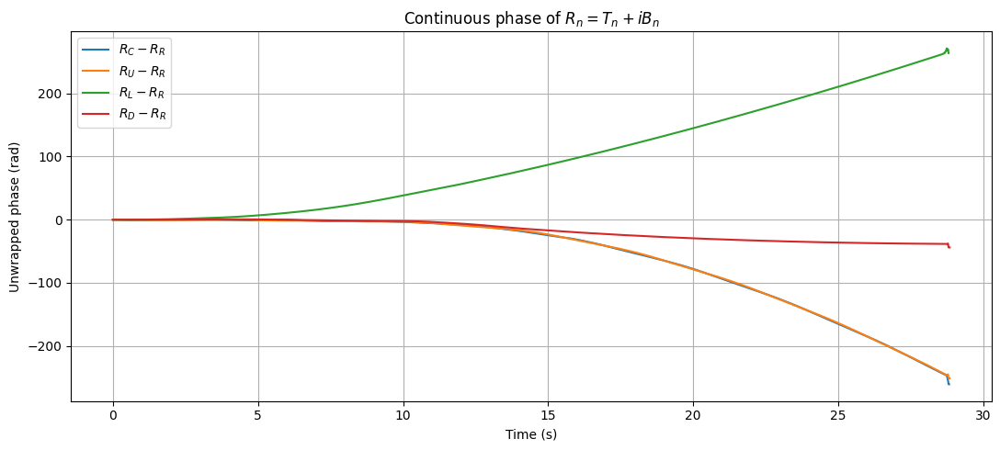

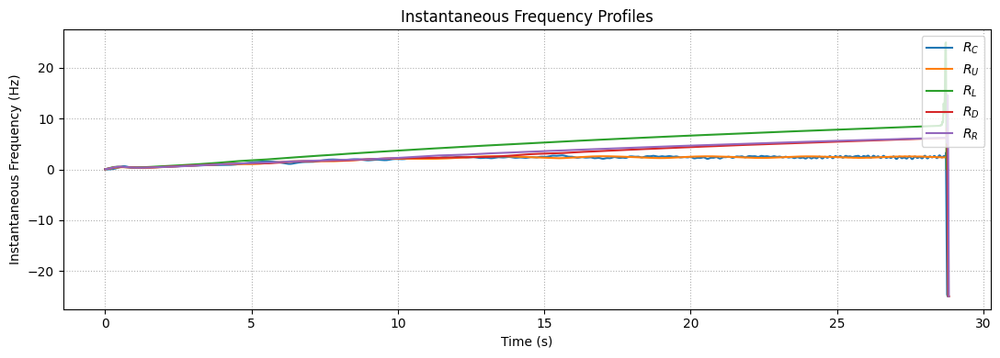

Final unwrapped phase values at last time step:
Node R_C: nan rad
Node R_U: nan rad
Node R_L: nan rad
Node R_D: nan rad
Node R_R: nan rad

--- Dominant Oscillator Frequencies ---
Node C: 0.0100 Hz
Node U: 0.0100 Hz
Node L: 0.0100 Hz
Node D: 0.0100 Hz
Node R: 0.0100 Hz


In [13]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [0.1, 0.3, 0.17, 0.15, 0.13]  # Higher dampening on Node U
    my_k0    = [1.0,  2.0,  1.5,  2.0,  3.0]  # Stiffer onsite spring on Node L
    my_kc    = [10.0, 10.0, 10.0, 10.0, 10.0] 
    #ka_v = 4
    #my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    my_ka    =  [0, 6, 10, 8, 7]
    sigmas = np.array([0, +1, +1, +1, +1], dtype=float)  # ferromagnet
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [6.0, 4.0, 5.0, 3.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        fs = 50,
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=100.0, # Shortened simulation length for quicker visualization testing
        sigmas = sigmas
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

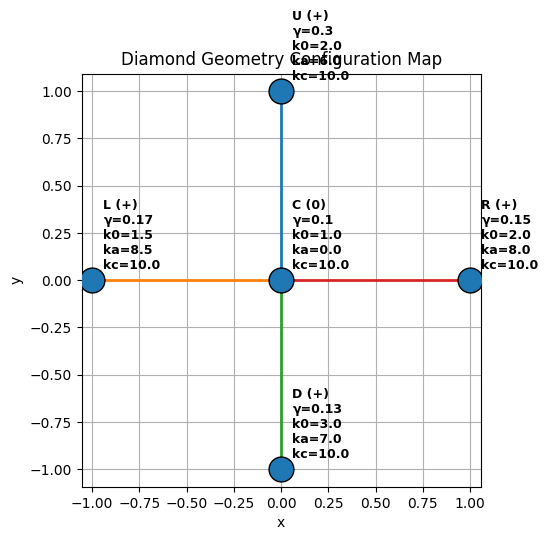

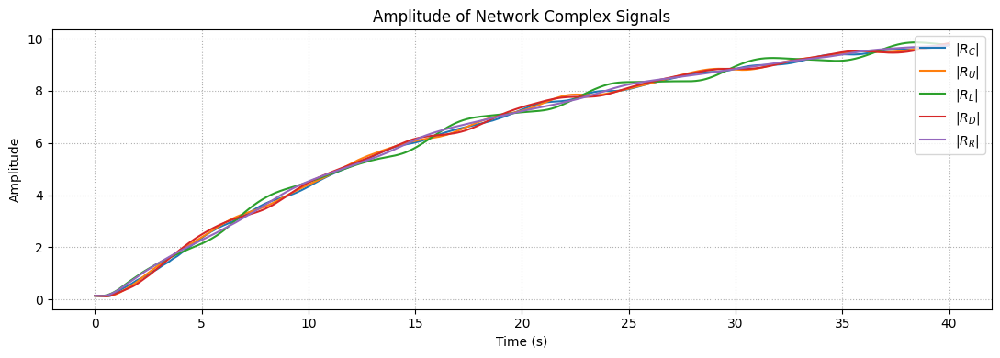

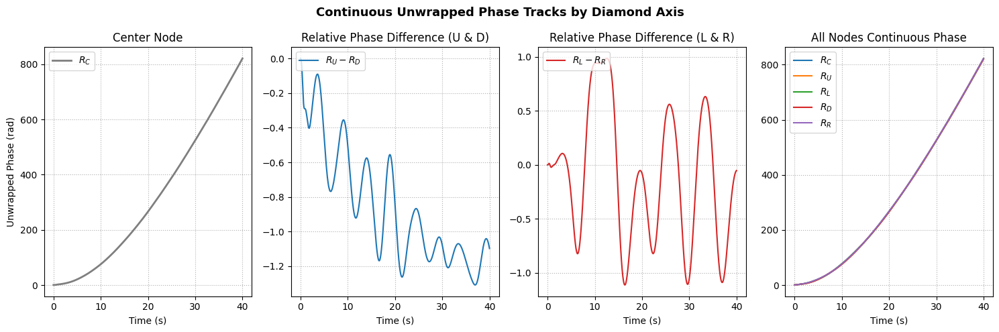

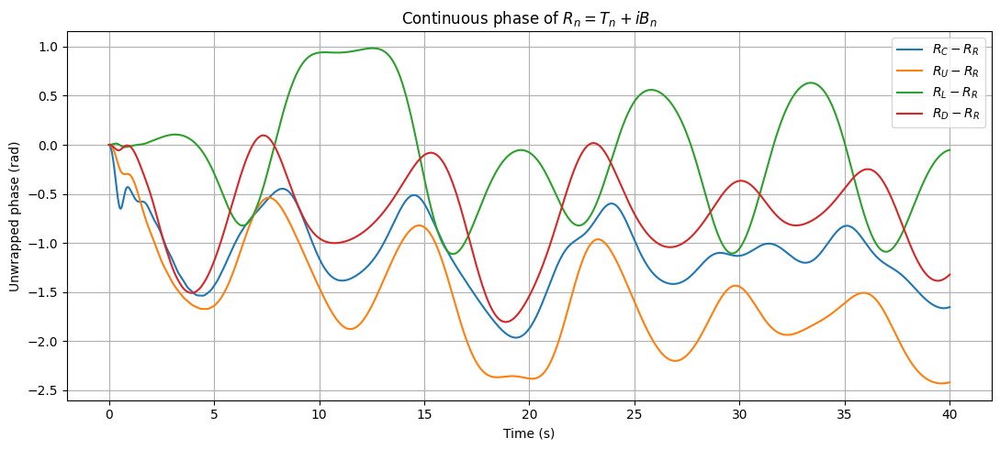

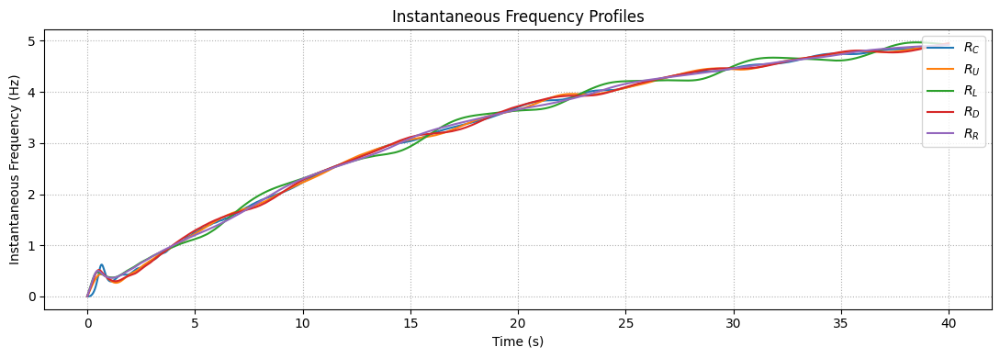


--- Dominant Oscillator Frequencies ---
Node C: 4.7750 Hz
Node U: 4.7750 Hz
Node L: 4.6250 Hz
Node D: 4.7750 Hz
Node R: 4.8000 Hz


In [87]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [0.1, 0.3, 0.17, 0.13, 0.15]  # Higher dampening on Node U
    my_k0    = [1.0,  2.0,  1.5,  3.0,  2.0]  # Stiffer onsite spring on Node L
    my_kc    = [10.0, 10.0, 10.0, 10.0, 10.0] 
    #ka_v = 4
    #my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    my_ka    =  [0, 6, 8.5, 7, 8]
    sigmas = np.array([0, +1, +1, +1, +1], dtype=float)  # ferromagnet
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [6.0, 4.0, 5.0, 3.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=40.0, # Shortened simulation length for quicker visualization testing
        sigmas = sigmas
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

I found a case where they don't synchronize: all have high activity (but different) and neighbour coupling is considerably smaller for the unsychronized one.

## 2-8-2026 look for steady state

I increased simulation time to look for steady state. I found an explosion. SO i increaed the damping to 1, instead of 0.1.

>>> SAVING PLOTS TO THIS FOLDER: c:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code


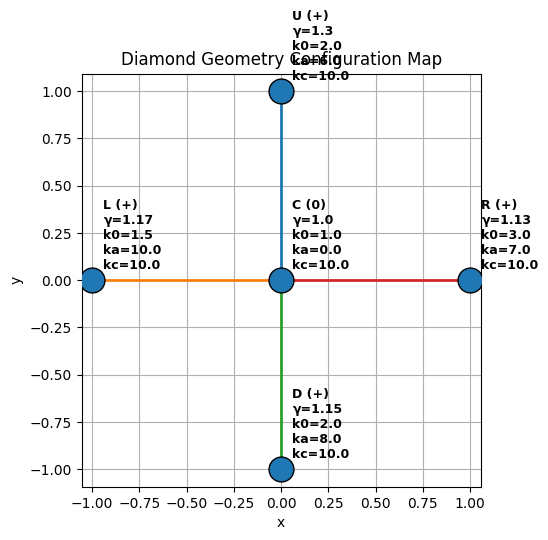

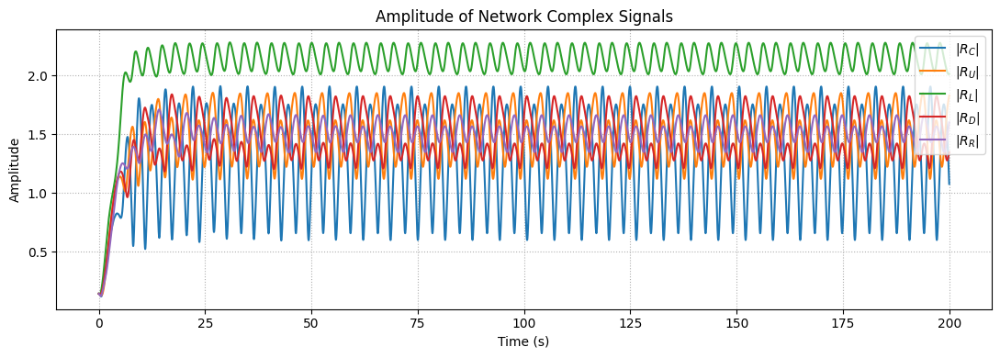

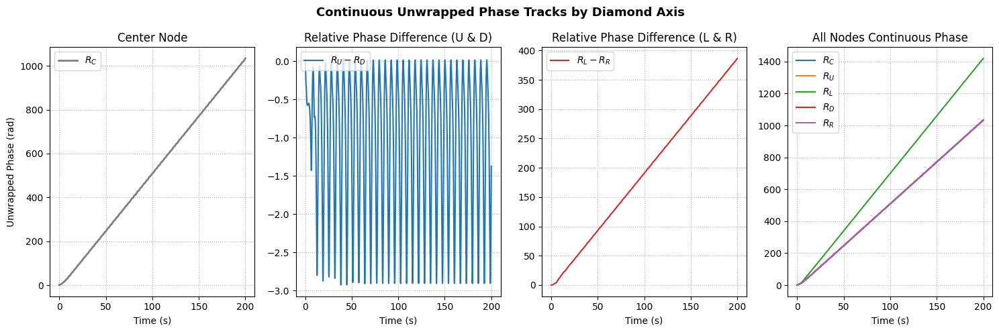

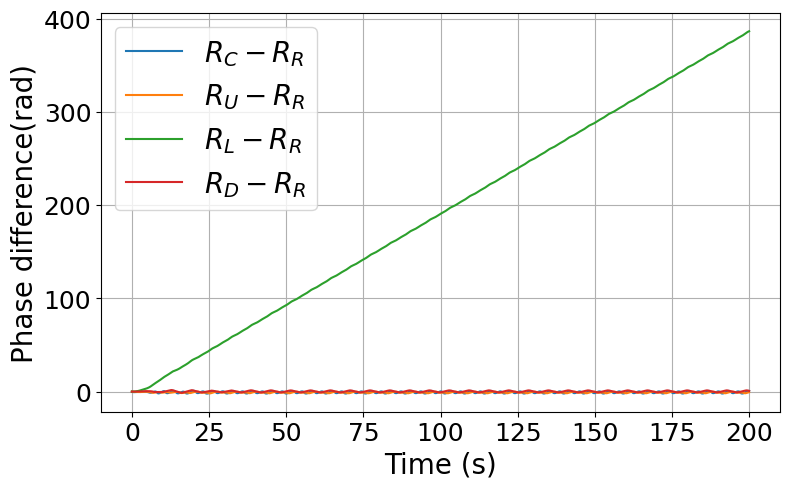

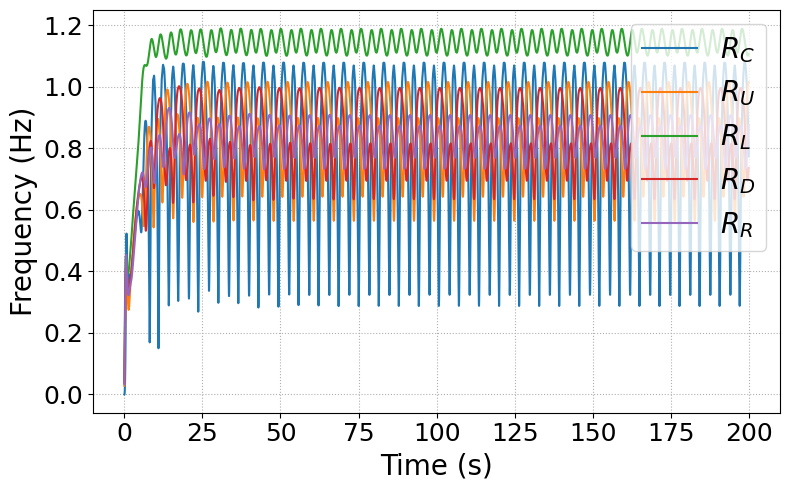

Final unwrapped phase values at last time step:
Node R_C: 1033.4533 rad
Node R_U: 1032.1393 rad
Node R_L: 1419.2803 rad
Node R_D: 1033.5126 rad
Node R_R: 1032.7145 rad
All plots saved successfully in: C:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code

--- Dominant Oscillator Frequencies ---
Node C: 0.8350 Hz
Node U: 0.8350 Hz
Node L: 1.1450 Hz
Node D: 0.8350 Hz
Node R: 0.8350 Hz


In [108]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [1, 1.3, 1.17, 1.15, 1.13]  # Higher dampening on Node U
    my_k0    = [1.0,  2.0,  1.5,  2.0,  3.0]  # Stiffer onsite spring on Node L
    my_kc    = [10.0, 10.0, 10.0, 10.0, 10.0] 
    #ka_v = 4
    #my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    my_ka    =  [0, 6, 10, 8, 7]
    sigmas = np.array([0, +1, +1, +1, +1], dtype=float)  # ferromagnet
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [6.0, 4.0, 5.0, 3.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        name_file="cross_original_sync",
        fs = 50,
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=200.0, # Shortened simulation length for quicker visualization testing
        sigmas = sigmas
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

Change ka of left site:

>>> SAVING PLOTS TO THIS FOLDER: c:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code


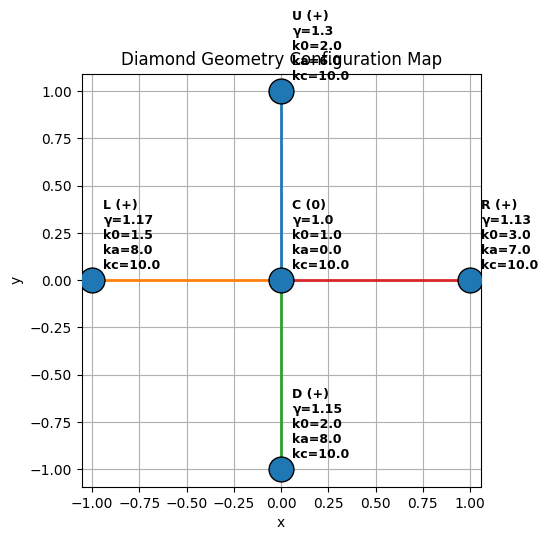

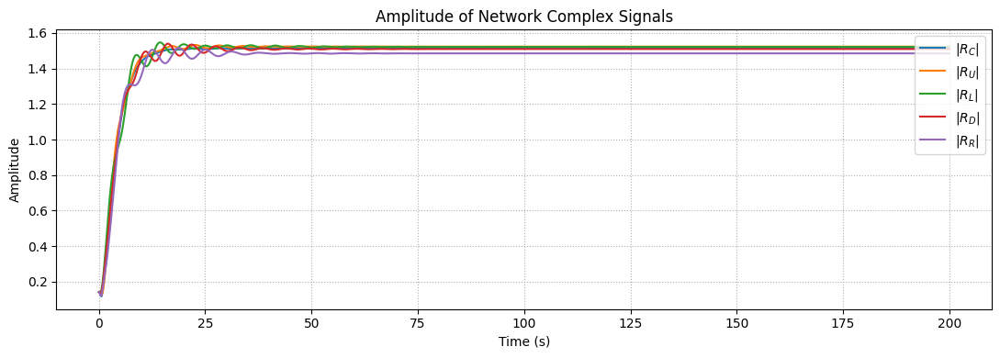

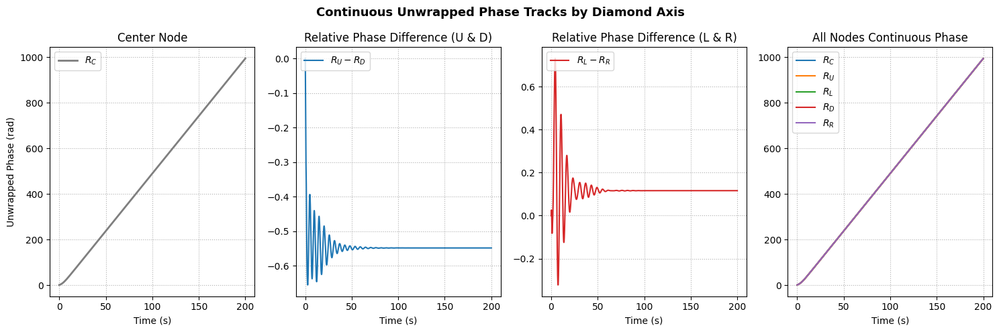

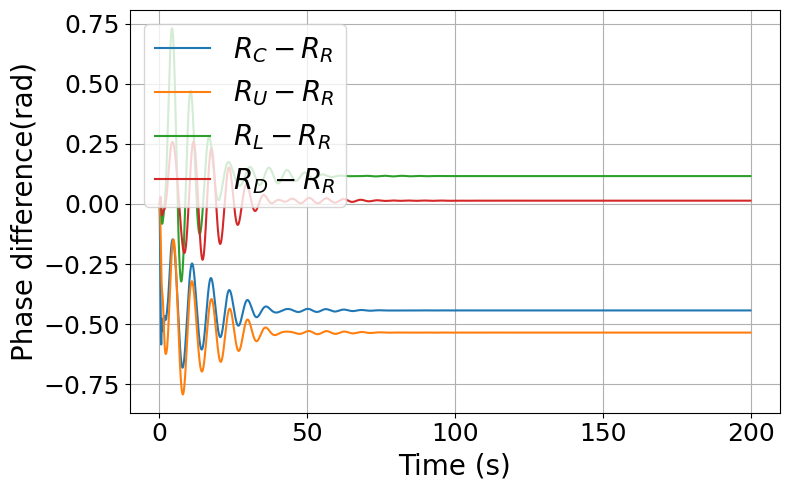

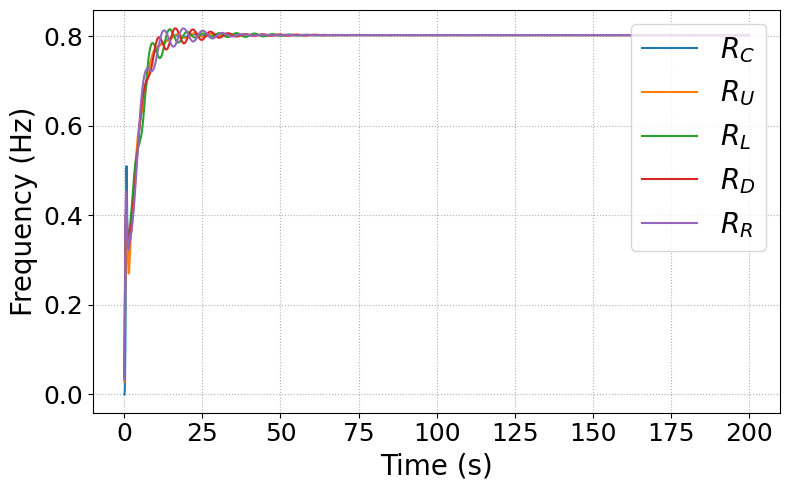

Final unwrapped phase values at last time step:
Node R_C: 993.8376 rad
Node R_U: 993.7455 rad
Node R_L: 994.3961 rad
Node R_D: 994.2939 rad
Node R_R: 994.2801 rad
All plots saved successfully in: C:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code

--- Dominant Oscillator Frequencies ---
Node C: 0.8050 Hz
Node U: 0.8050 Hz
Node L: 0.8050 Hz
Node D: 0.8050 Hz
Node R: 0.8050 Hz


In [109]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [1, 1.3, 1.17, 1.15, 1.13]  # Higher dampening on Node U
    my_k0    = [1.0,  2.0,  1.5,  2.0,  3.0]  # Stiffer onsite spring on Node L
    my_kc    = [10.0, 10.0, 10.0, 10.0, 10.0] 
    #ka_v = 4
    #my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    my_ka    =  [0, 6, 8, 8, 7]
    sigmas = np.array([0, +1, +1, +1, +1], dtype=float)  # ferromagnet
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [6.0, 4.0, 5.0, 3.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        name_file="cross_sync",
        fs = 50,
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=200.0, # Shortened simulation length for quicker visualization testing
        sigmas = sigmas
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

Change link coupling of L:

>>> SAVING PLOTS TO THIS FOLDER: c:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code


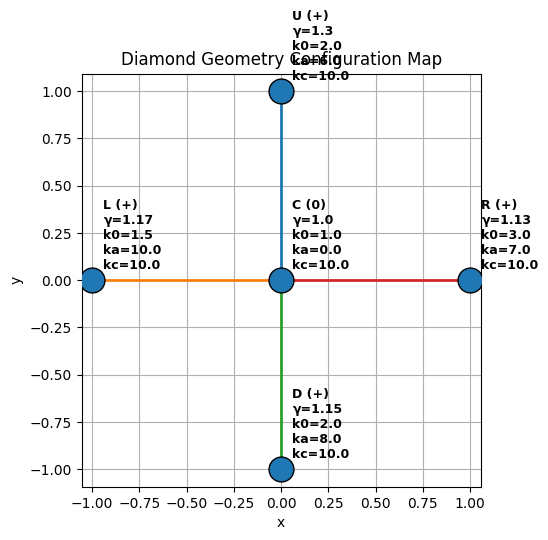

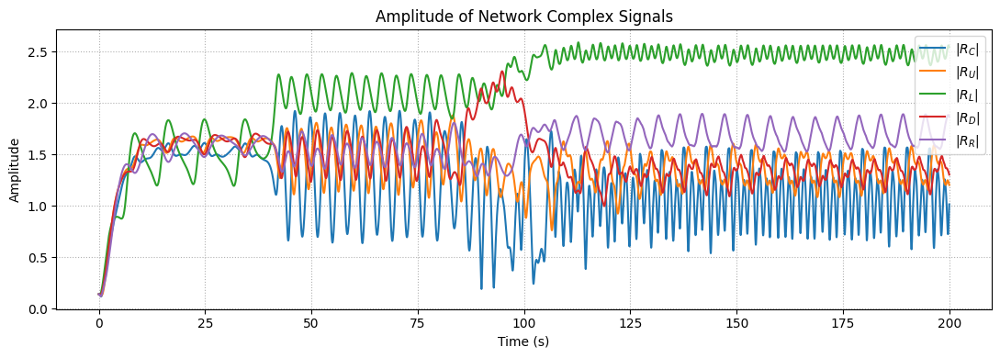

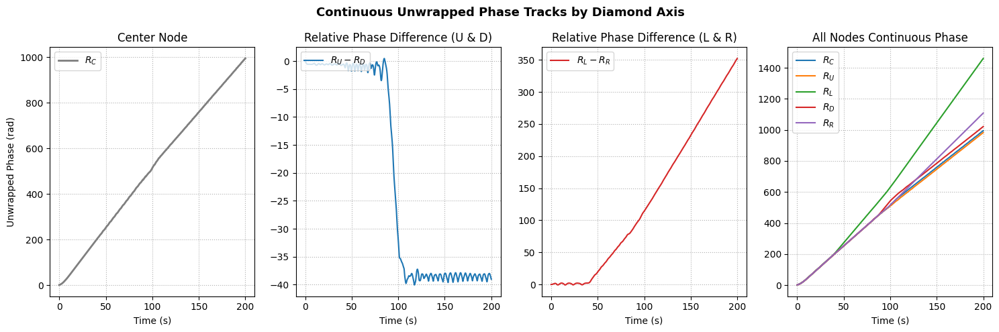

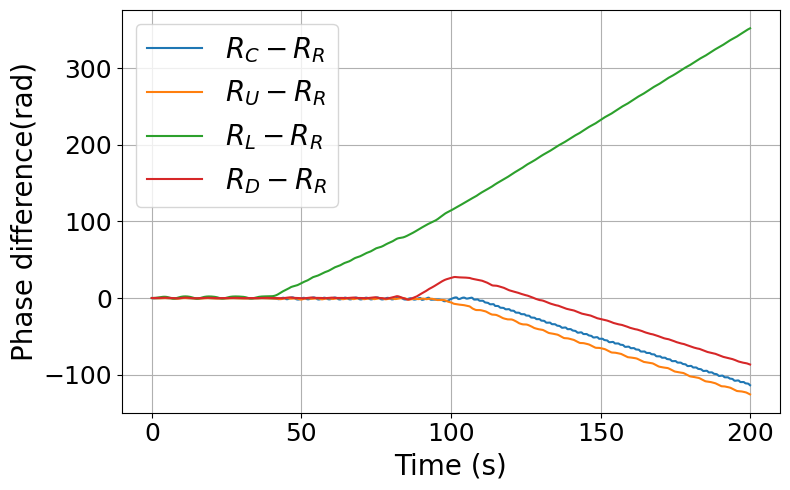

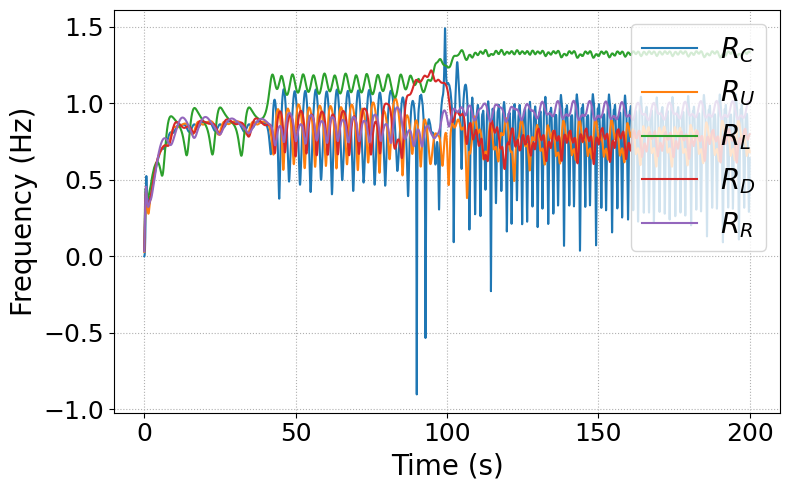

Final unwrapped phase values at last time step:
Node R_C: 994.4258 rad
Node R_U: 982.5089 rad
Node R_L: 1460.4554 rad
Node R_D: 1021.5285 rad
Node R_R: 1108.3323 rad
All plots saved successfully in: C:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code

--- Dominant Oscillator Frequencies ---
Node C: 0.8450 Hz
Node U: 0.7500 Hz
Node L: 1.3250 Hz
Node D: 0.7500 Hz
Node R: 0.9450 Hz


In [110]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [1, 1.3, 1.17, 1.15, 1.13]  # Higher dampening on Node U
    my_k0    = [1.0,  2.0,  1.5,  2.0,  3.0]  # Stiffer onsite spring on Node L
    my_kc    = [10.0, 10.0, 10.0, 10.0, 10.0] 
    #ka_v = 4
    #my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    my_ka    =  [0, 6, 10, 8, 7]
    sigmas = np.array([0, +1, +1, +1, +1], dtype=float)  # ferromagnet
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [6.0, 5.0, 5.0, 3.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        name_file="cross_nosync",
        fs = 50,
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=200.0, # Shortened simulation length for quicker visualization testing
        sigmas = sigmas
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

Now, R is also not synchronized with the rest. However, it doesn't synchronize with left.

Increase link coupling of left again:

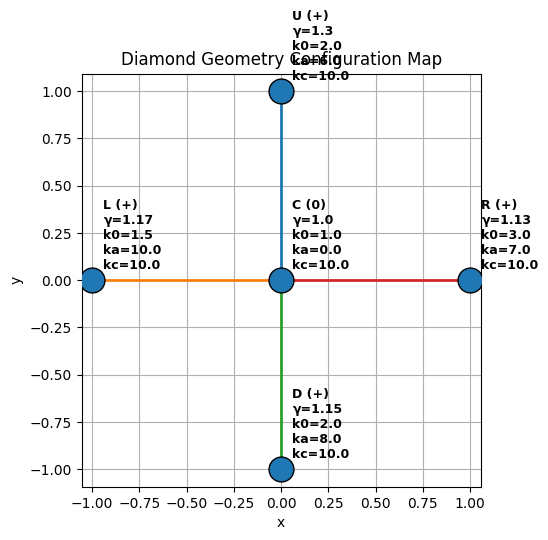

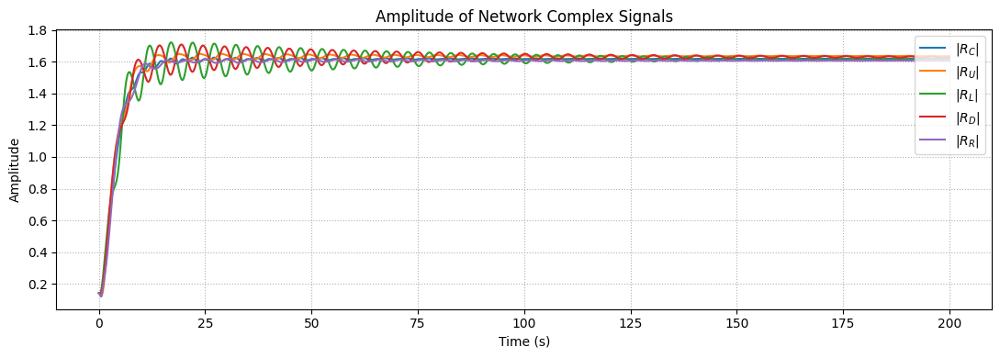

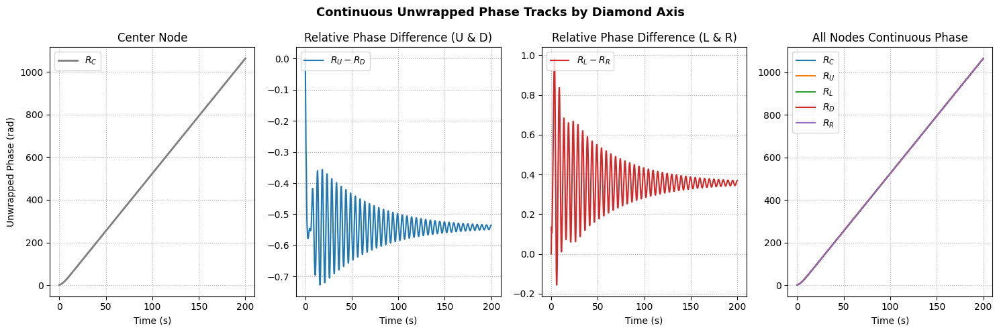

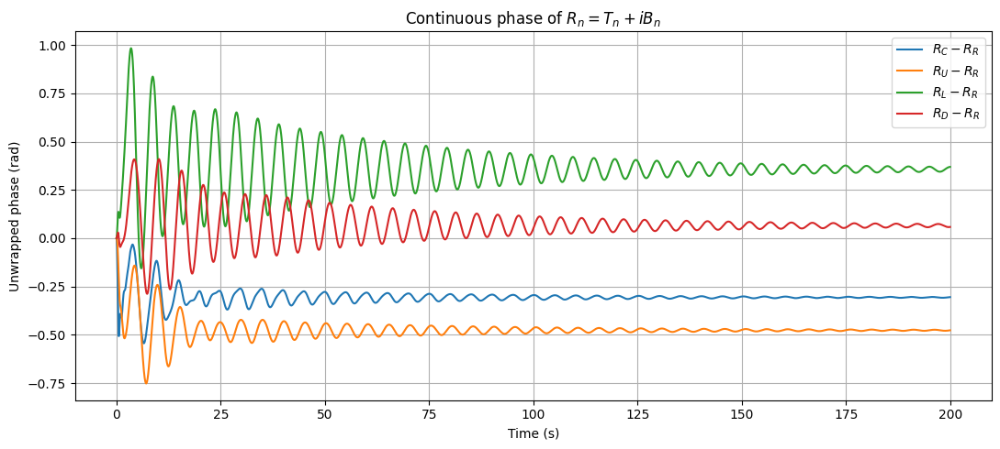

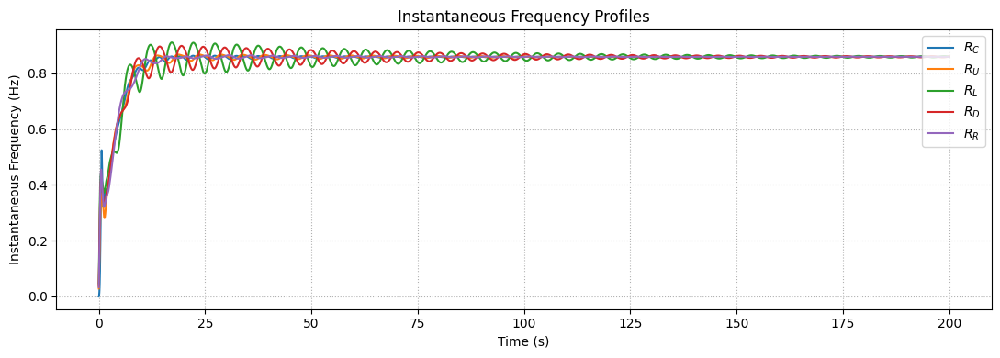

Final unwrapped phase values at last time step:
Node R_C: 1063.3887 rad
Node R_U: 1063.2170 rad
Node R_L: 1064.0626 rad
Node R_D: 1063.7518 rad
Node R_R: 1063.6935 rad

--- Dominant Oscillator Frequencies ---
Node C: 0.8600 Hz
Node U: 0.8600 Hz
Node L: 0.8600 Hz
Node D: 0.8600 Hz
Node R: 0.8600 Hz


In [18]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [1, 1.3, 1.17, 1.15, 1.13]  # Higher dampening on Node U
    my_k0    = [1.0,  2.0,  1.5,  2.0,  3.0]  # Stiffer onsite spring on Node L
    my_kc    = [10.0, 10.0, 10.0, 10.0, 10.0] 
    #ka_v = 4
    #my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    my_ka    =  [0, 6, 10, 8, 7]
    sigmas = np.array([0, +1, +1, +1, +1], dtype=float)  # ferromagnet
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [6.0, 6.0, 5.0, 3.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        fs = 50,
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=200.0, # Shortened simulation length for quicker visualization testing
        sigmas = sigmas
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

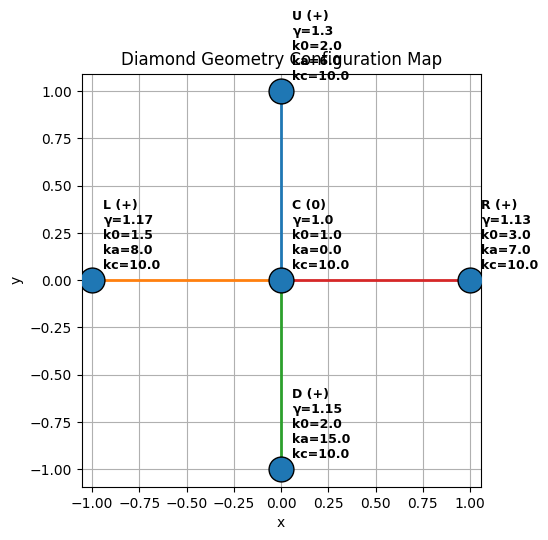

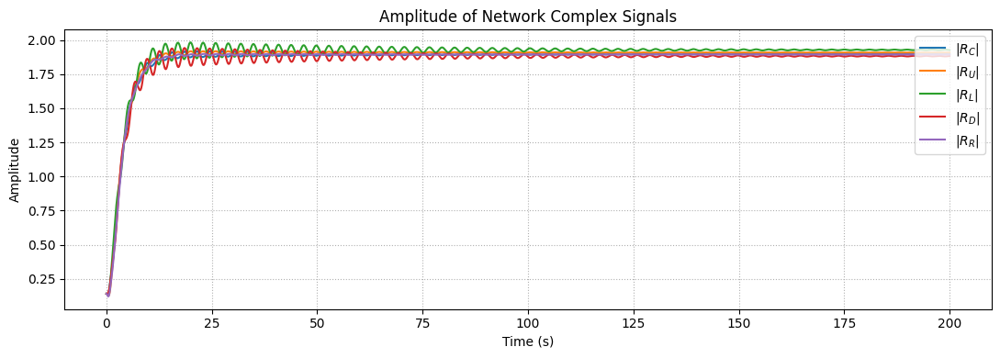

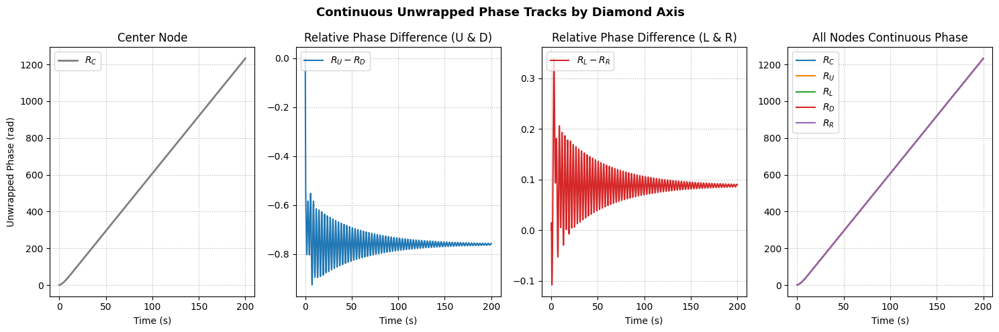

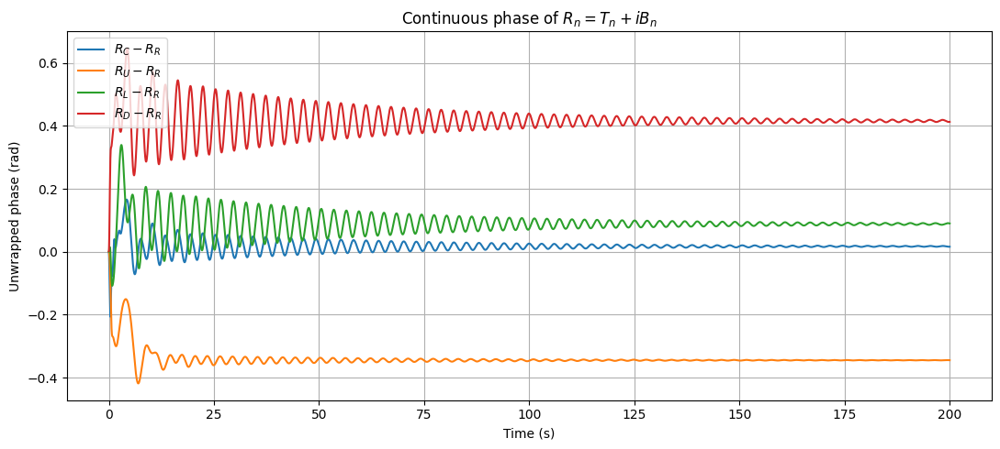

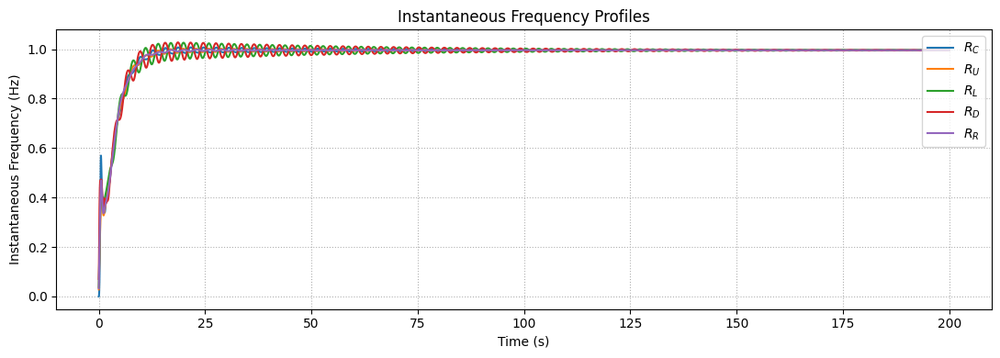

Final unwrapped phase values at last time step:
Node R_C: 1232.2391 rad
Node R_U: 1231.8783 rad
Node R_L: 1232.3130 rad
Node R_D: 1232.6361 rad
Node R_R: 1232.2231 rad

--- Dominant Oscillator Frequencies ---
Node C: 0.9950 Hz
Node U: 0.9950 Hz
Node L: 0.9950 Hz
Node D: 0.9950 Hz
Node R: 0.9950 Hz


In [23]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [1, 1.3, 1.17, 1.15, 1.13]  # Higher dampening on Node U
    my_k0    = [1.0,  2.0,  1.5,  2.0,  3.0]  # Stiffer onsite spring on Node L
    my_kc    = [10.0, 10.0, 10.0, 10.0, 10.0] 
    #ka_v = 4
    #my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    my_ka    =  [0, 6, 8, 15, 7]
    sigmas = np.array([0, +1, +1, +1, +1], dtype=float)  # ferromagnet
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [6.0, 10.0, 20.0, 3.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        fs = 50,
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=200.0, # Shortened simulation length for quicker visualization testing
        sigmas = sigmas
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

Looking for no sync at all, without changin neighbour coupling:

>>> SAVING PLOTS TO THIS FOLDER: c:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code


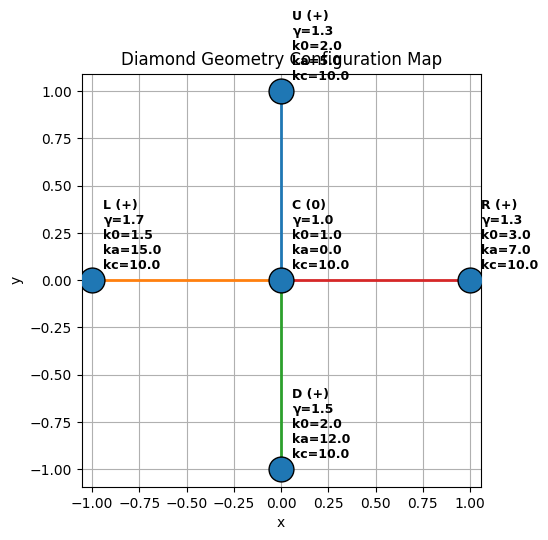

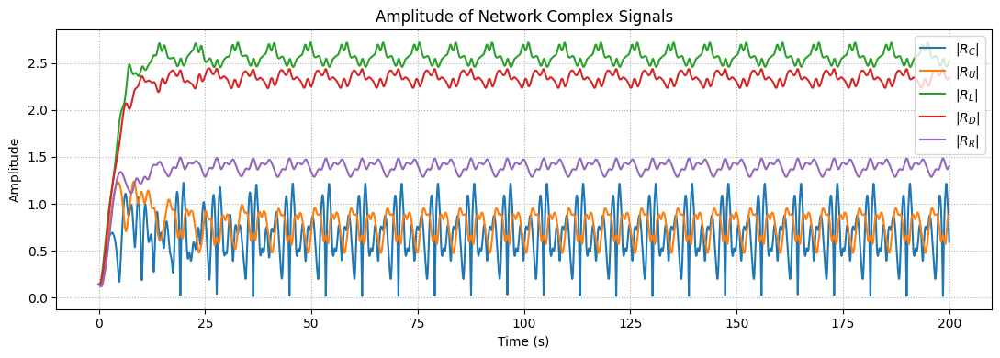

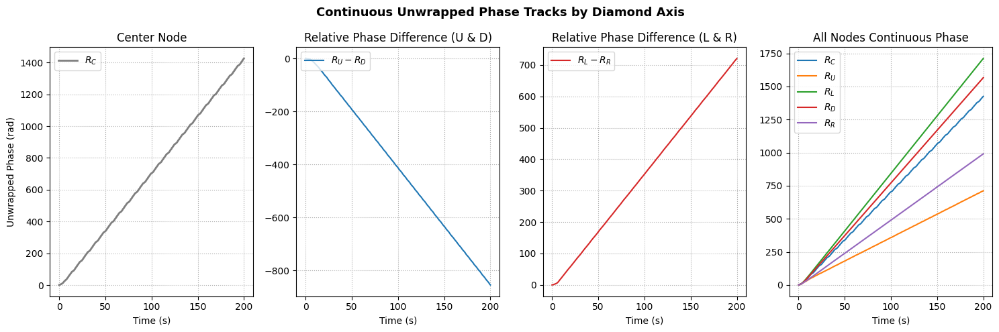

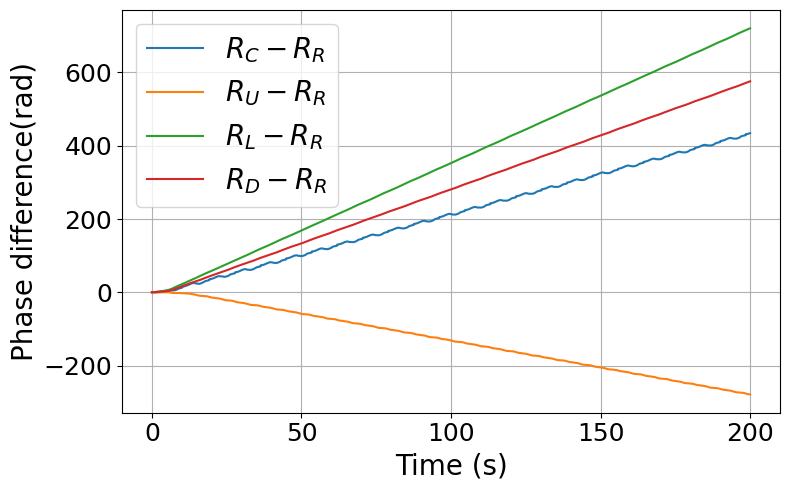

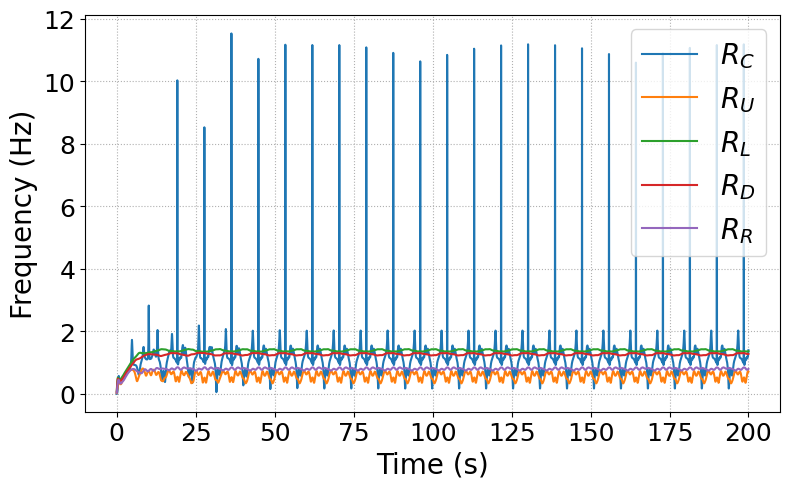

Final unwrapped phase values at last time step:
Node R_C: 1425.3322 rad
Node R_U: 712.0706 rad
Node R_L: 1711.5786 rad
Node R_D: 1566.8357 rad
Node R_R: 990.9631 rad
All plots saved successfully in: C:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code

--- Dominant Oscillator Frequencies ---
Node C: 1.2650 Hz
Node U: 0.5650 Hz
Node L: 1.3850 Hz
Node D: 1.2650 Hz
Node R: 0.7950 Hz


In [111]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [1, 1.3, 1.7, 1.5, 1.3]  # Higher dampening on Node U
    my_k0    = [1.0,  2.0,  1.5,  2.0,  3.0]  # Stiffer onsite spring on Node L
    my_kc    = [10.0, 10.0, 10.0, 10.0, 10.0] 
    #ka_v = 4
    #my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    my_ka    =  [0, 5, 15, 12, 7]
    sigmas = np.array([0, +1, +1, +1, +1], dtype=float)  # ferromagnet
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [6.0, 6.0, 5.0, 3.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        name_file="cross_nosync_atall",
        fs = 50,
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=200.0, # Shortened simulation length for quicker visualization testing
        sigmas = sigmas
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

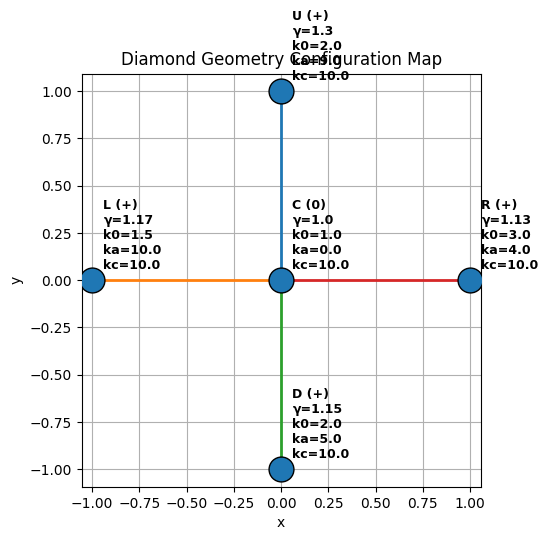

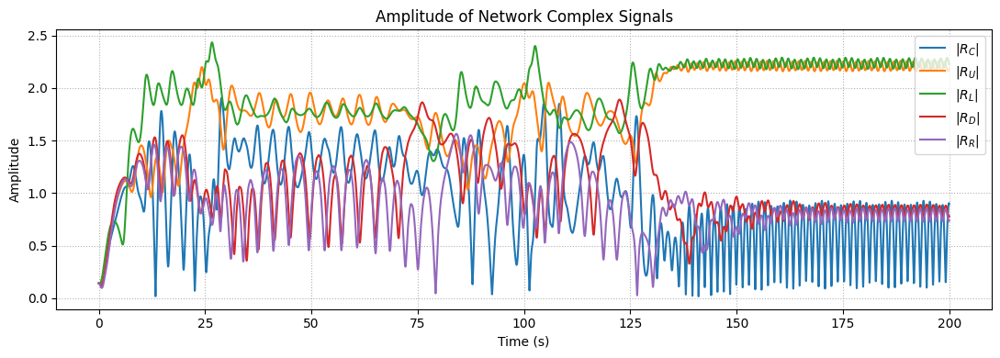

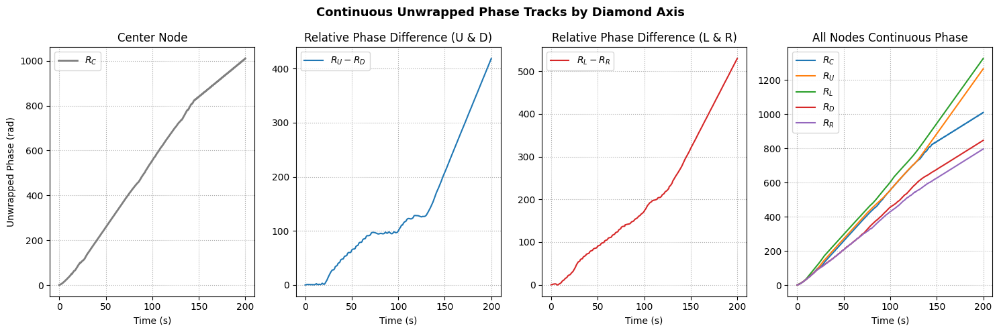

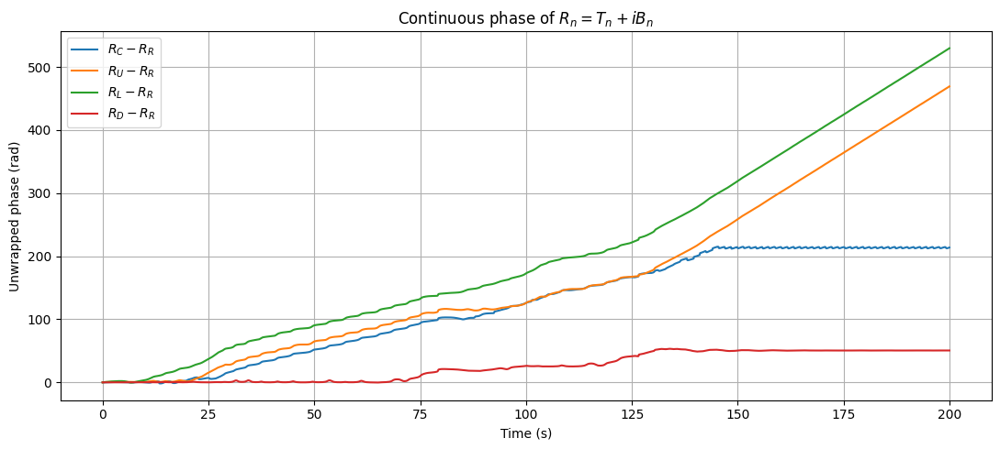

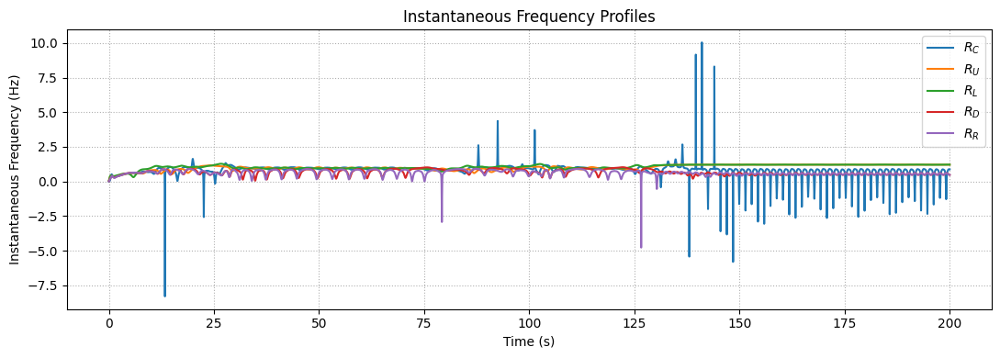

Final unwrapped phase values at last time step:
Node R_C: 1010.3677 rad
Node R_U: 1265.8524 rad
Node R_L: 1326.3750 rad
Node R_D: 847.0958 rad
Node R_R: 796.5417 rad

--- Dominant Oscillator Frequencies ---
Node C: 0.9500 Hz
Node U: 1.2100 Hz
Node L: 1.2100 Hz
Node D: 0.5400 Hz
Node R: 0.5400 Hz


In [30]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [1, 1.3, 1.17, 1.15, 1.13]  # Higher dampening on Node U
    my_k0    = [1.0,  2.0,  1.5,  2.0,  3.0]  # Stiffer onsite spring on Node L
    my_kc    = [10.0, 10.0, 10.0, 10.0, 10.0] 
    #ka_v = 4
    #my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    my_ka    =  [0, 9, 10, 5, 4]
    sigmas = np.array([0, +1, +1, +1, +1], dtype=float)  # ferromagnet
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [6.0, 6.0, 6.0, 6.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        fs = 50,
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=200.0, # Shortened simulation length for quicker visualization testing
        sigmas = sigmas
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

### Interesting

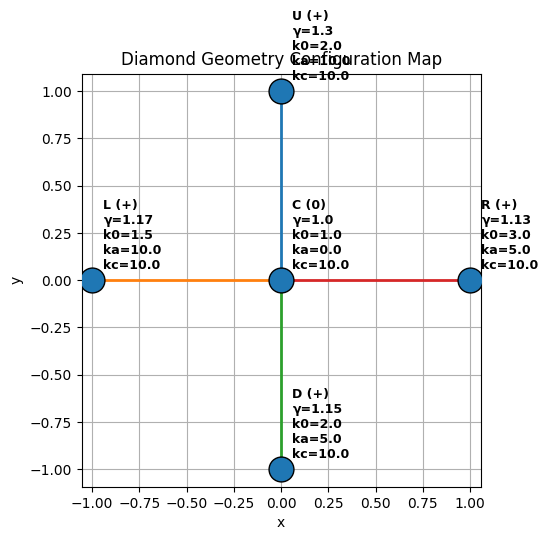

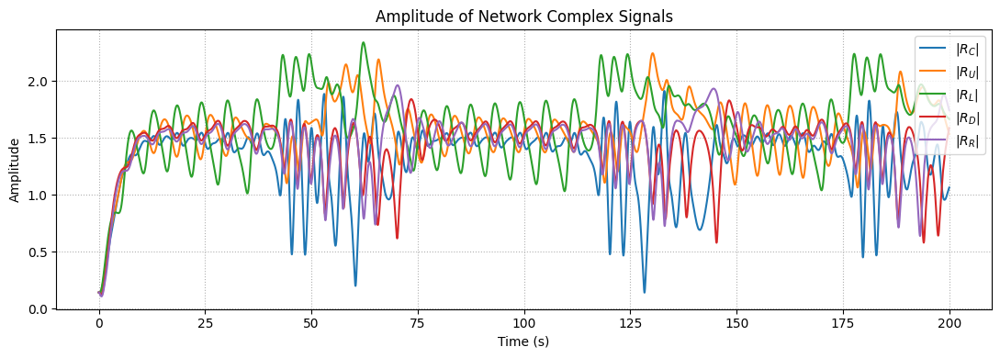

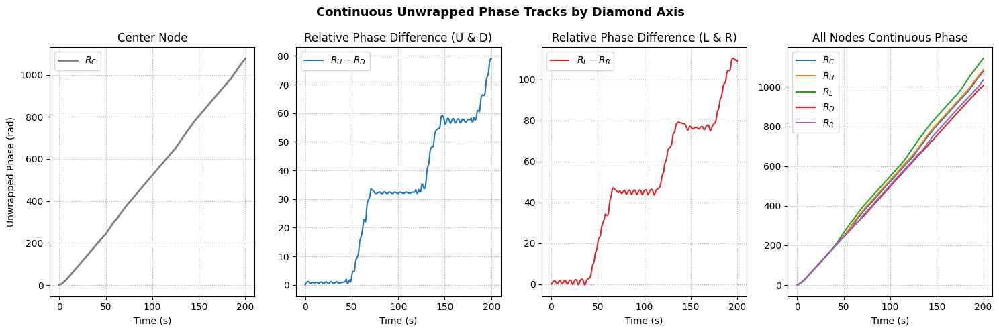

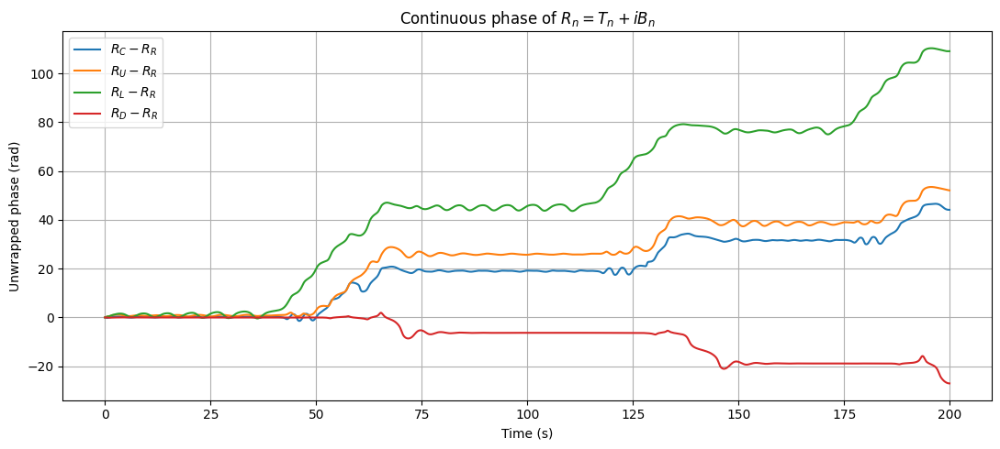

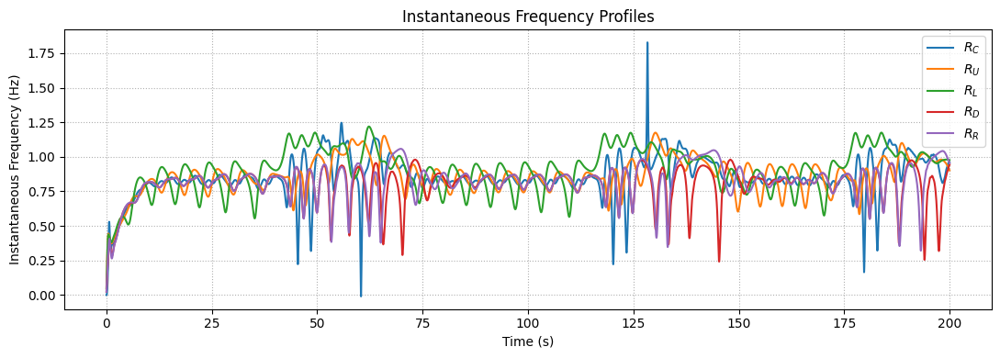

Final unwrapped phase values at last time step:
Node R_C: 1077.7563 rad
Node R_U: 1085.7129 rad
Node R_L: 1142.7474 rad
Node R_D: 1006.6287 rad
Node R_R: 1033.6611 rad

--- Dominant Oscillator Frequencies ---
Node C: 0.8200 Hz
Node U: 0.8350 Hz
Node L: 0.8350 Hz
Node D: 0.8200 Hz
Node R: 0.8200 Hz


In [37]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [1, 1.3, 1.17, 1.15, 1.13]  # Higher dampening on Node U
    my_k0    = [1.0,  2.0,  1.5,  2.0,  3.0]  # Stiffer onsite spring on Node L
    my_kc    = [10.0, 10.0, 10.0, 10.0, 10.0] 
    #ka_v = 4
    #my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    my_ka    =  [0, 10, 10, 5, 5]
    sigmas = np.array([0, +1, +1, +1, +1], dtype=float)  # ferromagnet
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [6.0, 6.0, 6.0, 6.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        fs = 50,
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=200.0, # Shortened simulation length for quicker visualization testing
        sigmas = sigmas
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

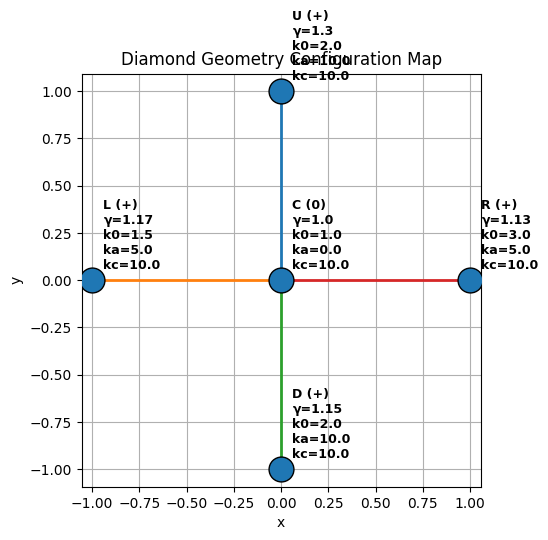

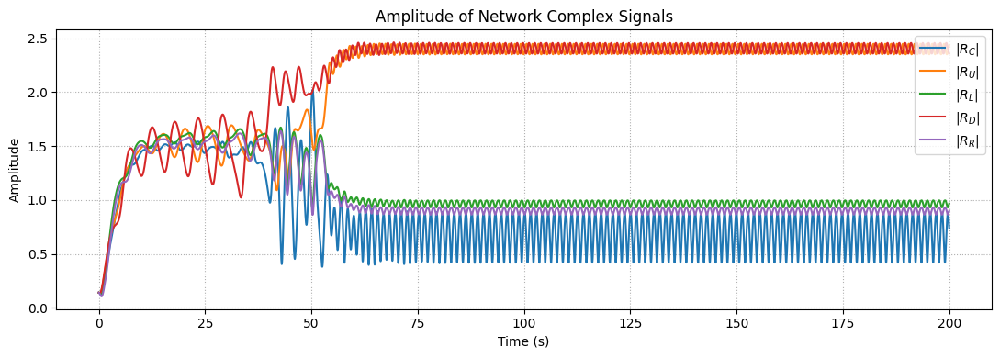

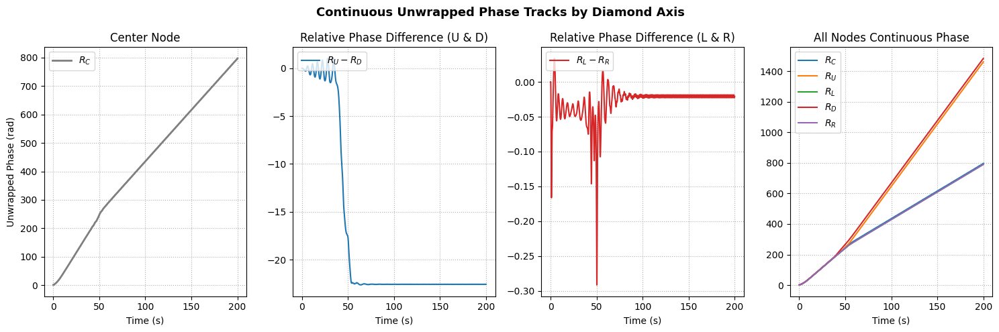

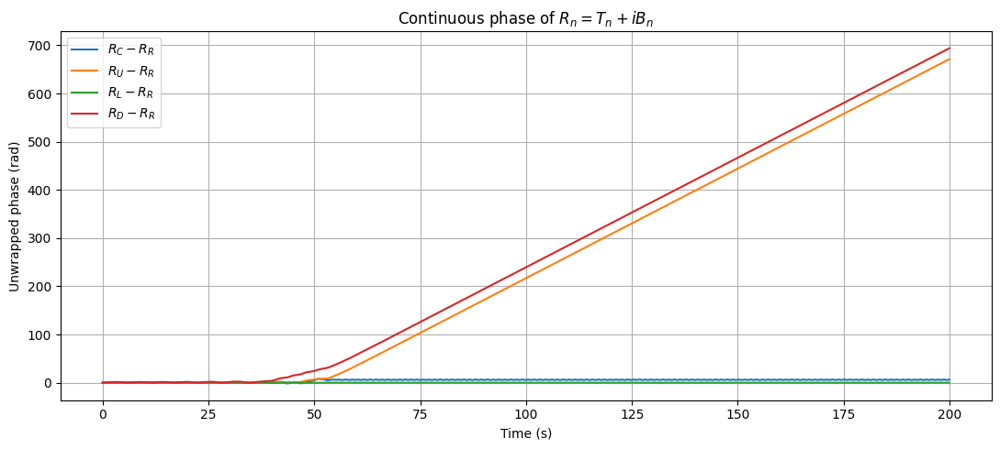

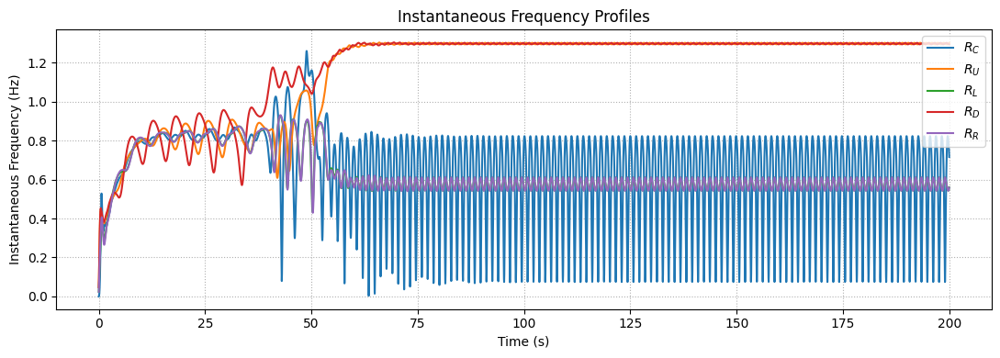

Final unwrapped phase values at last time step:
Node R_C: 796.9488 rad
Node R_U: 1461.8362 rad
Node R_L: 790.4148 rad
Node R_D: 1484.4220 rad
Node R_R: 790.4356 rad

--- Dominant Oscillator Frequencies ---
Node C: 0.5750 Hz
Node U: 1.3000 Hz
Node L: 0.5750 Hz
Node D: 1.3000 Hz
Node R: 0.5750 Hz


In [38]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [1, 1, 1, 1, 1]  # Higher dampening on Node U
    my_k0    = [2.0,  2.0,  2.0,  2.0,  2.0]  # Stiffer onsite spring on Node L
    my_kc    = [10.0, 10.0, 10.0, 10.0, 10.0] 
    #ka_v = 4
    #my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    my_ka    =  [0, 10, 5, 10, 5]
    sigmas = np.array([0, +1, +1, +1, +1], dtype=float)  # ferromagnet
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [6.0, 6.0, 6.0, 6.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        fs = 50,
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=200.0, # Shortened simulation length for quicker visualization testing
        sigmas = sigmas
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

### Make units identical: eliminate disorder

>>> SAVING PLOTS TO THIS FOLDER: c:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code


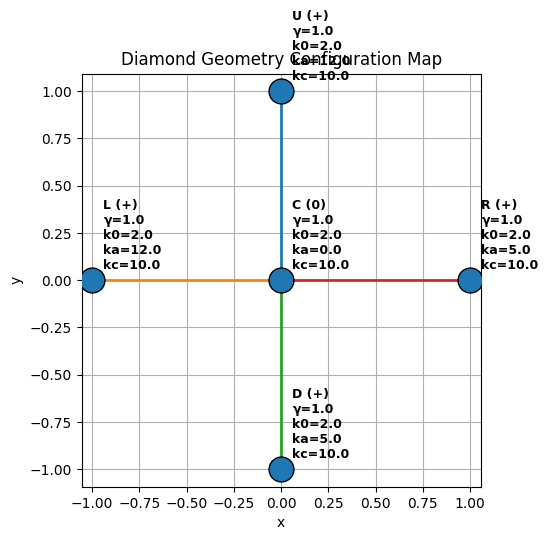

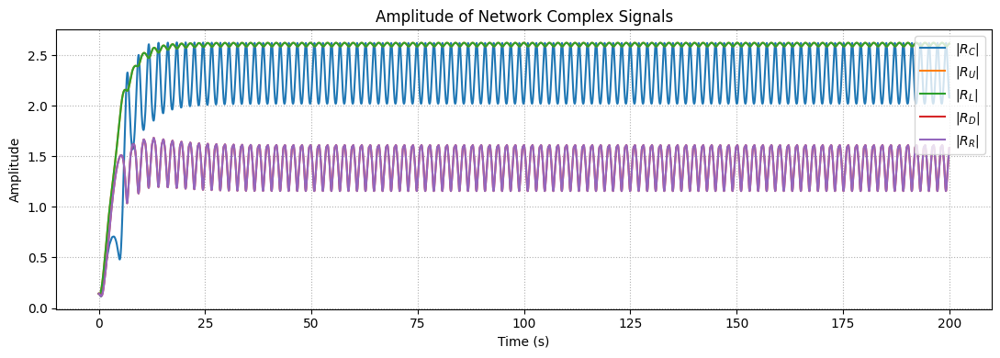

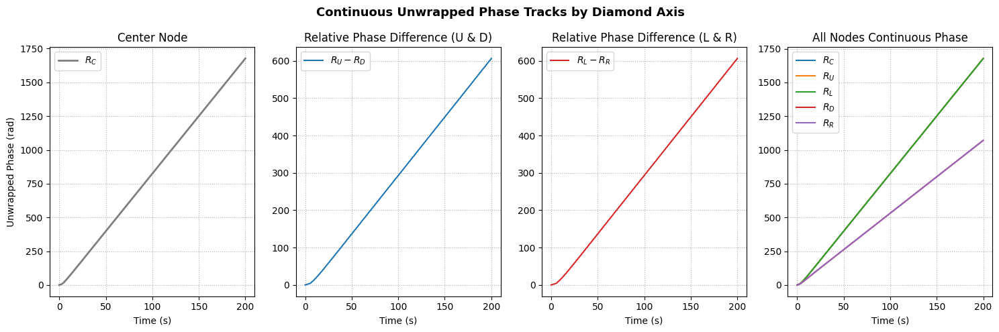

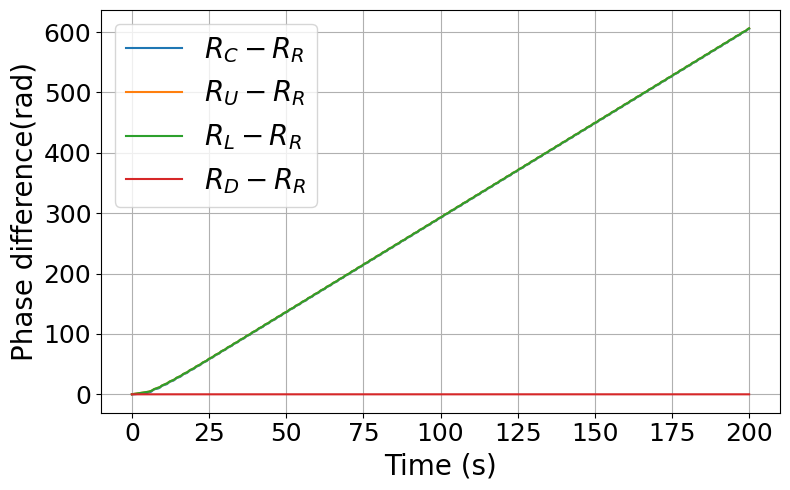

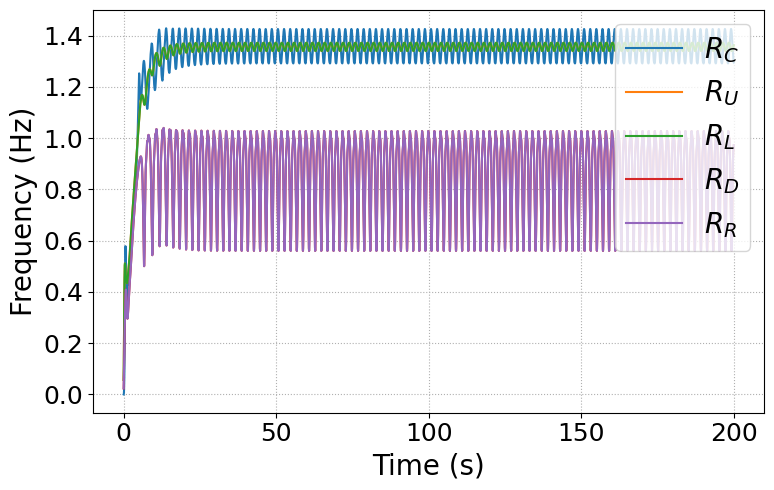

Final unwrapped phase values at last time step:
Node R_C: 1676.7815 rad
Node R_U: 1677.4460 rad
Node R_L: 1677.4460 rad
Node R_D: 1071.1294 rad
Node R_R: 1071.1294 rad
All plots saved successfully in: C:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code

--- Dominant Oscillator Frequencies ---
Node C: 1.3550 Hz
Node U: 1.3550 Hz
Node L: 1.3550 Hz
Node D: 0.8600 Hz
Node R: 0.8600 Hz


In [112]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [1, 1, 1, 1, 1]  # Higher dampening on Node U
    my_k0    = [2.0,  2.0,  2.0,  2.0,  2.0]  # Stiffer onsite spring on Node L
    my_kc    = [10.0, 10.0, 10.0, 10.0, 10.0] 
    #ka_v = 4
    #my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    my_ka    =  [0, 12, 12, 5, 5]
    sigmas = np.array([0, +1, +1, +1, +1], dtype=float)  # ferromagnet
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [6.0, 6.0, 6.0, 6.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        name_file="cross_UL",
        fs = 50,
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=200.0, # Shortened simulation length for quicker visualization testing
        sigmas = sigmas
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

>>> SAVING PLOTS TO THIS FOLDER: c:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code


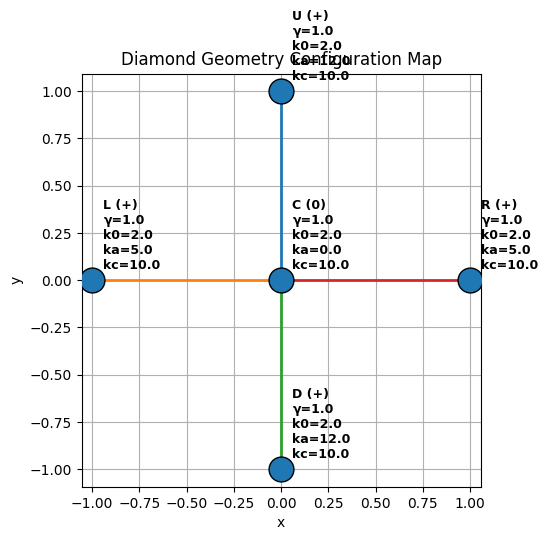

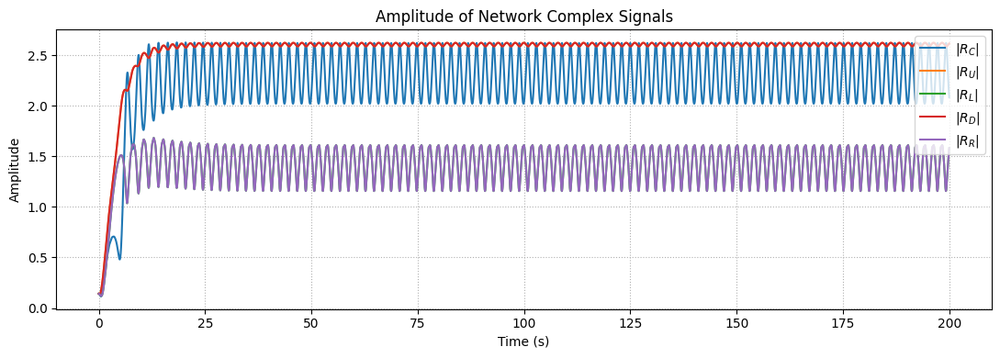

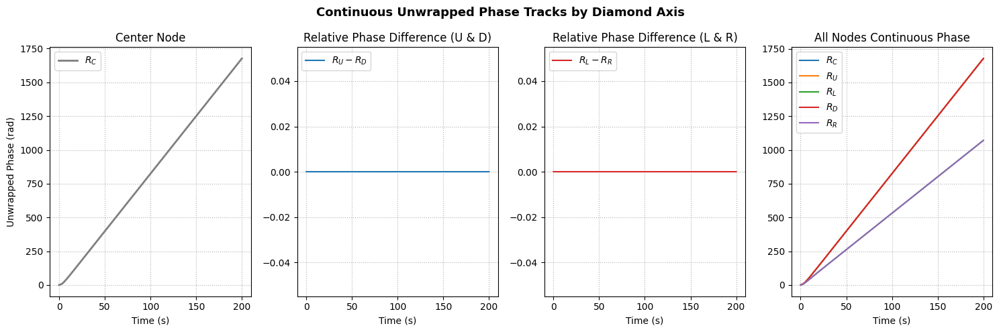

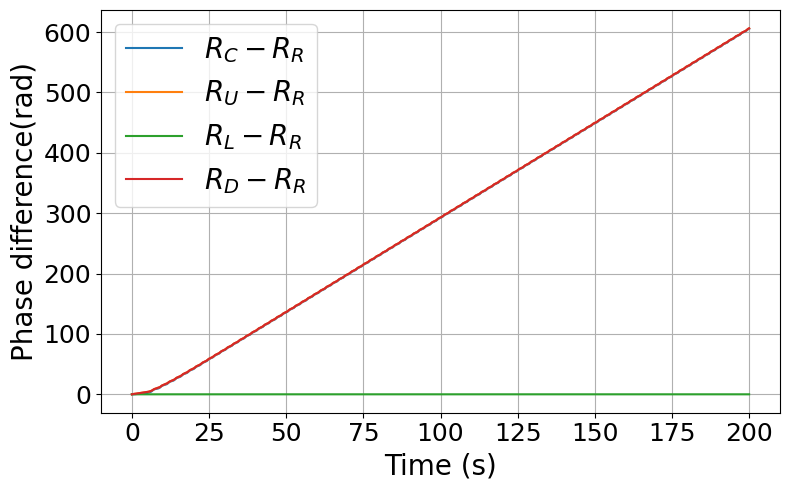

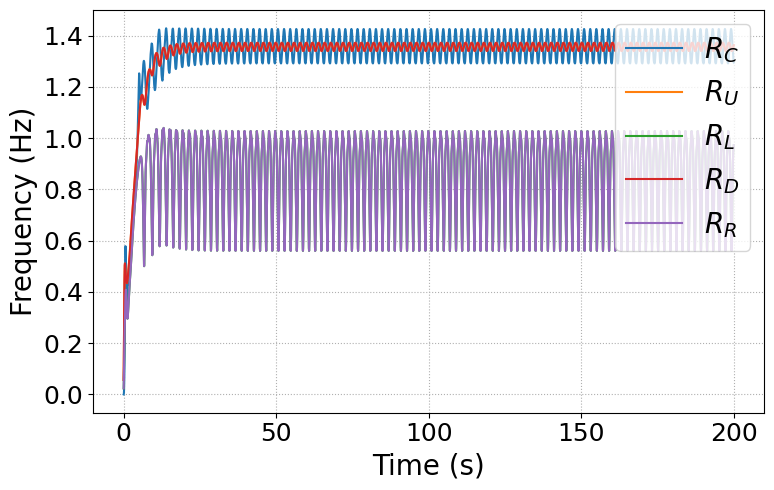

Final unwrapped phase values at last time step:
Node R_C: 1676.7815 rad
Node R_U: 1677.4460 rad
Node R_L: 1071.1294 rad
Node R_D: 1677.4460 rad
Node R_R: 1071.1294 rad
All plots saved successfully in: C:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code

--- Dominant Oscillator Frequencies ---
Node C: 1.3550 Hz
Node U: 1.3550 Hz
Node L: 0.8600 Hz
Node D: 1.3550 Hz
Node R: 0.8600 Hz


In [113]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [1, 1, 1, 1, 1]  # Higher dampening on Node U
    my_k0    = [2.0,  2.0,  2.0,  2.0,  2.0]  # Stiffer onsite spring on Node L
    my_kc    = [10.0, 10.0, 10.0, 10.0, 10.0] 
    #ka_v = 4
    #my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    my_ka    =  [0, 12, 5, 12, 5]
    sigmas = np.array([0, +1, +1, +1, +1], dtype=float)  # ferromagnet
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [6.0, 6.0, 6.0, 6.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        name_file="cross_UD",
        fs = 50,
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=200.0, # Shortened simulation length for quicker visualization testing
        sigmas = sigmas
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

## Altermagnet 2-8-2026 

>>> SAVING PLOTS TO THIS FOLDER: c:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code


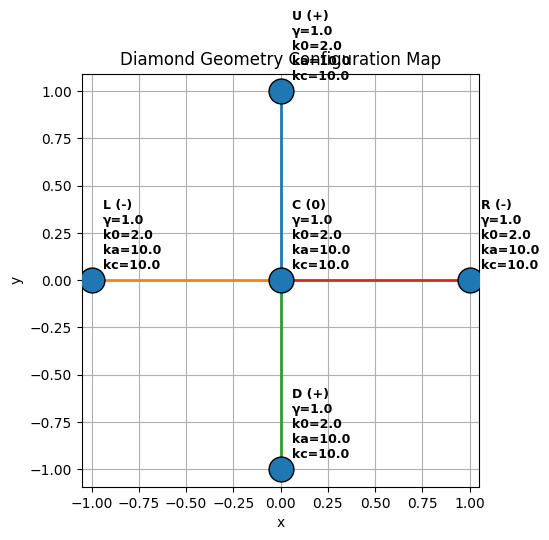

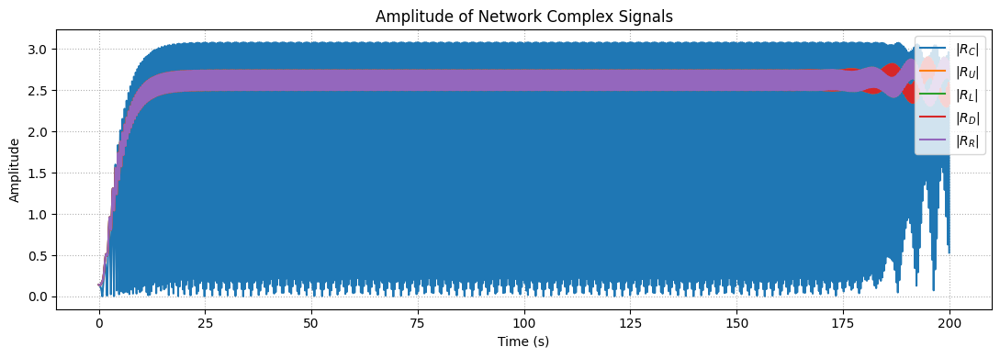

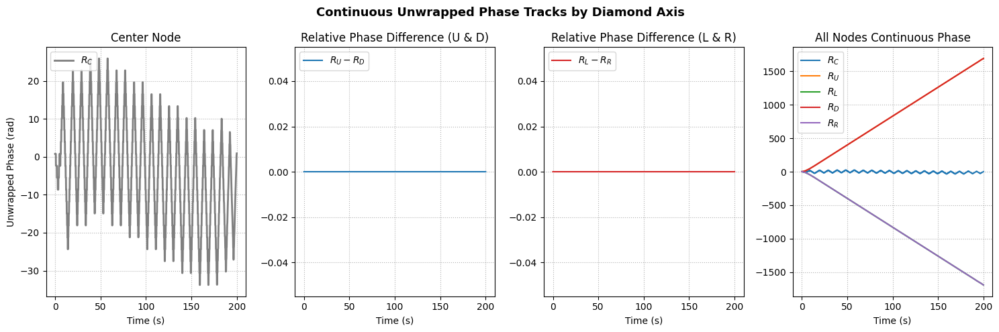

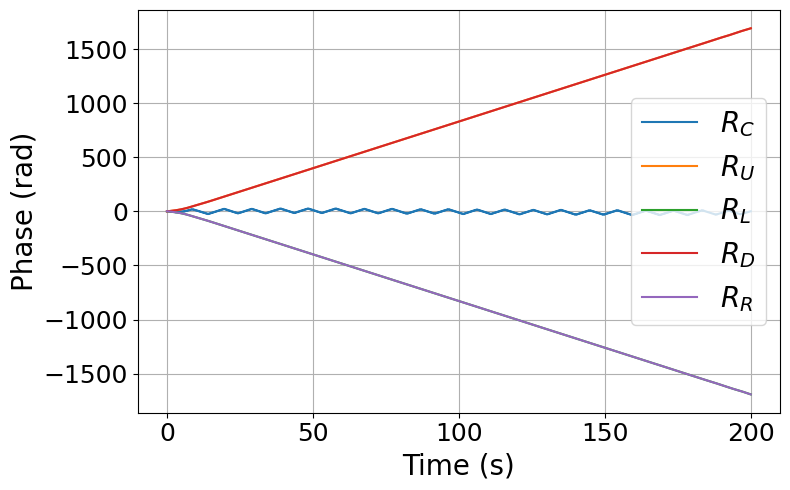

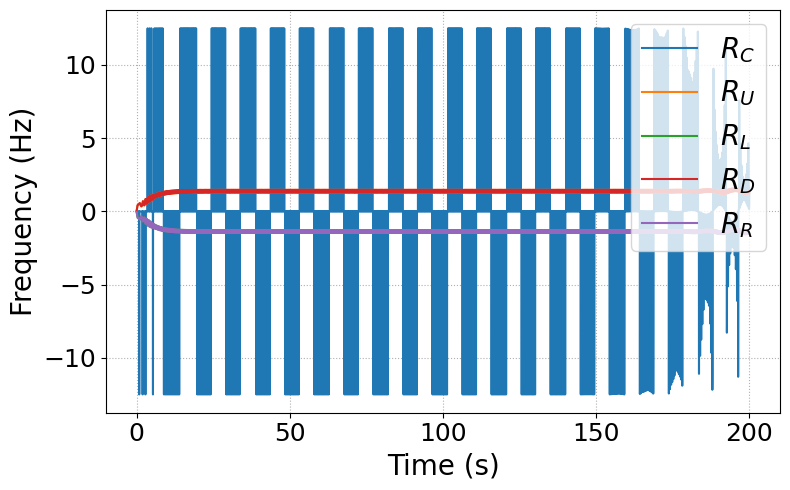

Final unwrapped phase values at last time step:
Node R_C: 0.8917 rad
Node R_U: 1692.1640 rad
Node R_L: -1691.9243 rad
Node R_D: 1692.1640 rad
Node R_R: -1691.9243 rad
All plots saved successfully in: C:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code

--- Dominant Oscillator Frequencies ---
Node C: 1.3750 Hz
Node U: 1.3750 Hz
Node L: 1.3750 Hz
Node D: 1.3750 Hz
Node R: 1.3750 Hz


In [130]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [1, 1, 1, 1, 1]  # Higher dampening on Node U
    my_k0    = [2.0,  2.0,  2.0,  2.0,  2.0]  # Stiffer onsite spring on Node L
    my_kc    = [10.0, 10.0, 10.0, 10.0, 10.0] 
    ka_v = 10
    my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    #my_ka    =  [0, 6, 6, 6, 6]
    sigmas = np.array([0, +1, -1, +1, -1], dtype=float)  # ferromagnet
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [6.0, 6.0, 6.0, 6.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        #name_file="",
        fs = 50,
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=200.0, # Shortened simulation length for quicker visualization testing
        sigmas = sigmas
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

>>> SAVING PLOTS TO THIS FOLDER: c:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code


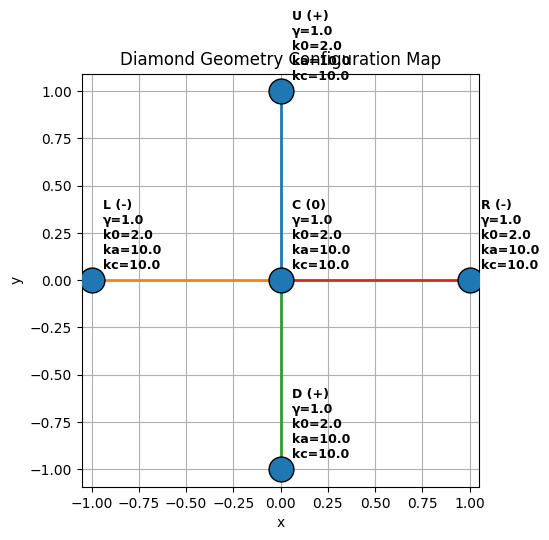

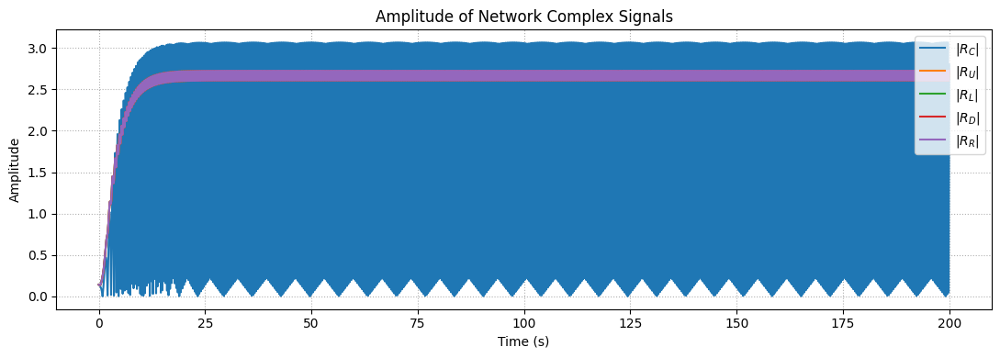

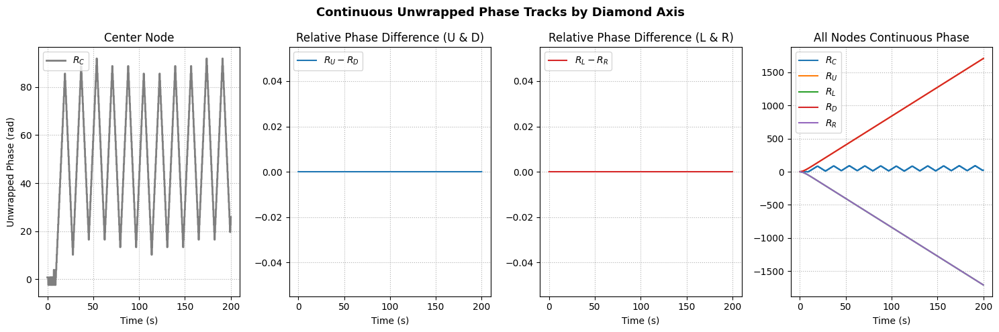

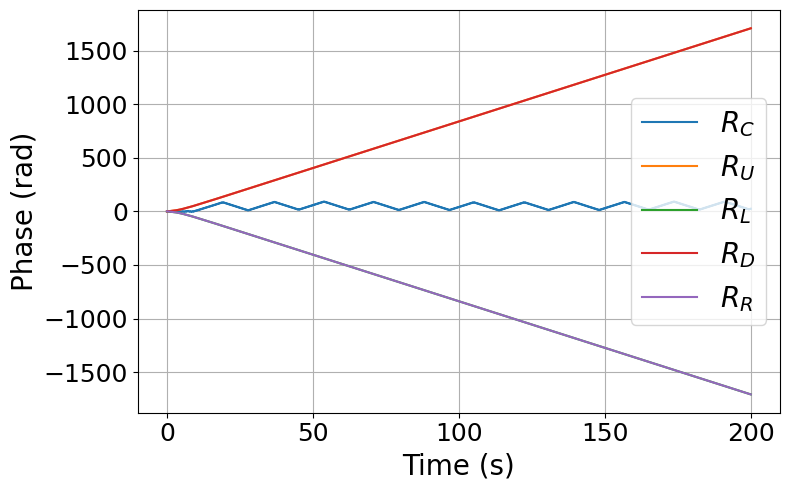

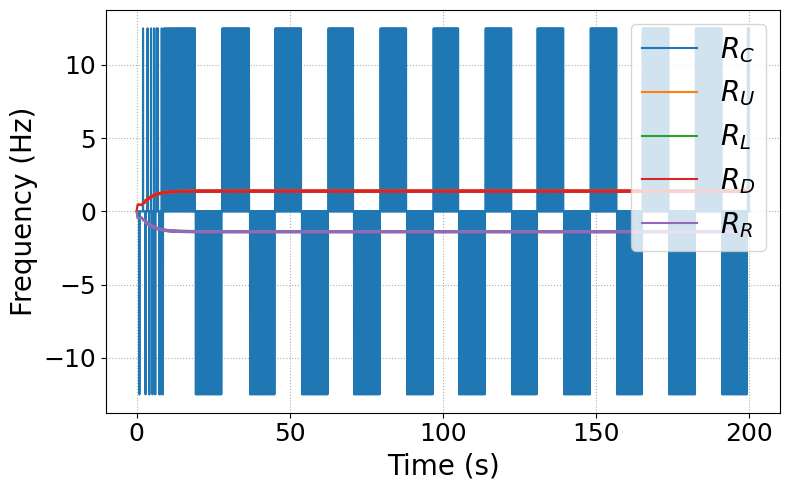

Final unwrapped phase values at last time step:
Node R_C: 25.9181 rad
Node R_U: 1710.3906 rad
Node R_L: -1708.8198 rad
Node R_D: 1710.3906 rad
Node R_R: -1708.8198 rad
All plots saved successfully in: C:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code

--- Dominant Oscillator Frequencies ---
Node C: 1.3850 Hz
Node U: 1.3850 Hz
Node L: 1.3850 Hz
Node D: 1.3850 Hz
Node R: 1.3850 Hz


In [134]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [1, 1, 1, 1, 1]  # Higher dampening on Node U
    my_k0    = [2.0,  2.0,  2.0,  2.0,  2.0]  # Stiffer onsite spring on Node L
    my_kc    = [10.0, 10.0, 10.0, 10.0, 10.0] 
    ka_v = 10
    my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    #my_ka    =  [0, 3, 3, 3, 3]
    sigmas = np.array([0, +1, -1, +1, -1], dtype=float)  # ferromagnet
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [3.0, 3.0, 3.0, 3.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        name_file="cross_altermagnet_symmetric",
        fs = 50,
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=200.0, # Shortened simulation length for quicker visualization testing
        sigmas = sigmas
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")

>>> SAVING PLOTS TO THIS FOLDER: c:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code


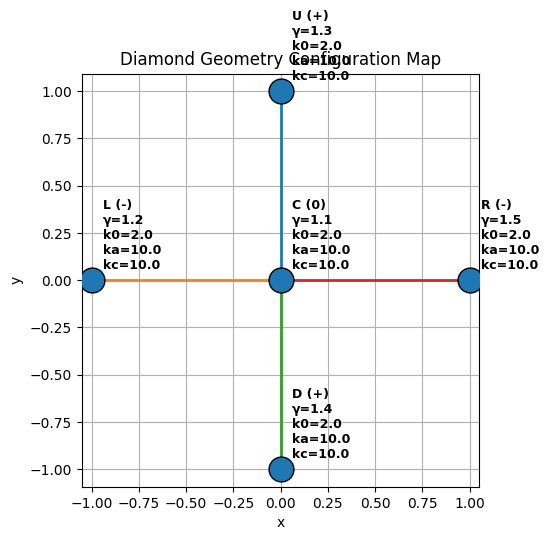

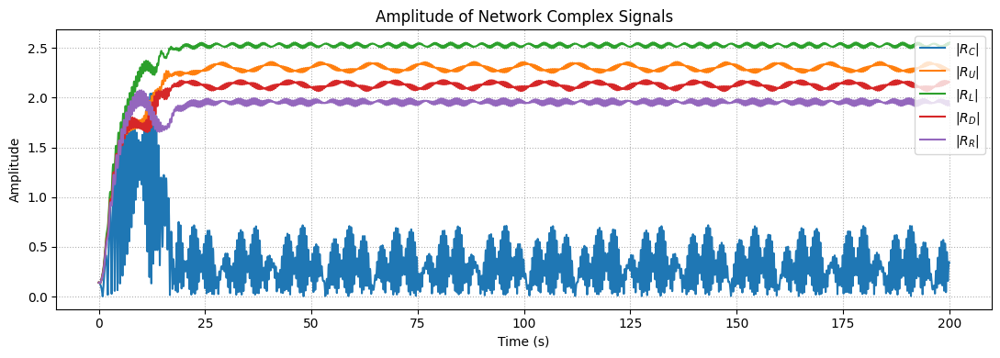

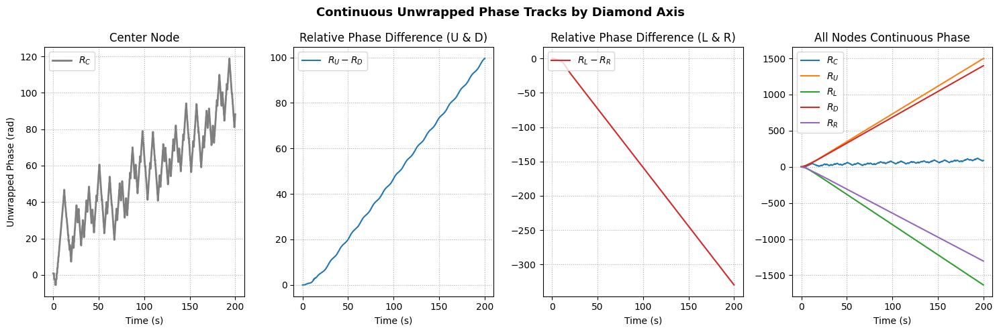

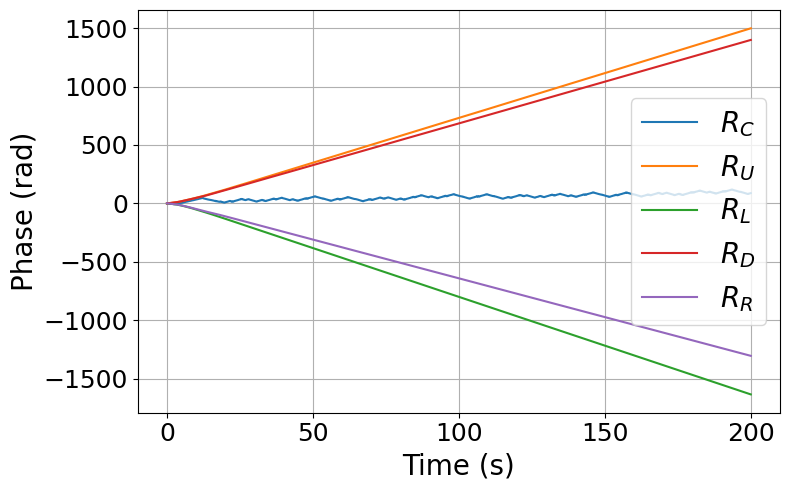

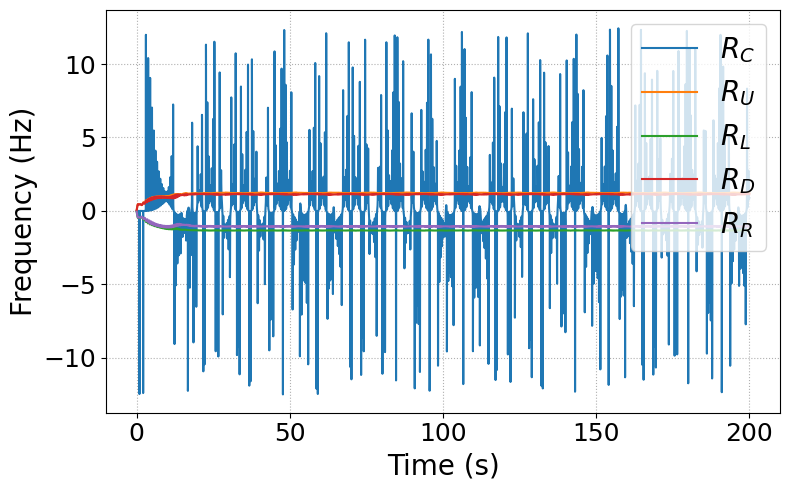

Final unwrapped phase values at last time step:
Node R_C: 88.1614 rad
Node R_U: 1498.1077 rad
Node R_L: -1633.6099 rad
Node R_D: 1398.5968 rad
Node R_R: -1303.6852 rad
All plots saved successfully in: C:\Users\profesor\OneDrive - UvA\Documents\Amsterdam\Thesis\Mechanical altermagnet code

--- Dominant Oscillator Frequencies ---
Node C: 1.1350 Hz
Node U: 1.2200 Hz
Node L: 1.1350 Hz
Node D: 1.1350 Hz
Node R: 1.2200 Hz


In [136]:
# ==========================================
# Execution Block: Define your parameters here
# ==========================================
if __name__ == "__main__":
    
    # Example Custom Array Layout (Injecting custom values into Node 'U' [index 1])
    # order of nodes: [C, U, L, D, R]
    my_gamma = [1.1, 1.3, 1.2, 1.4, 1.5]  # Higher dampening on Node U
    my_k0    = [2.0,  2.0,  2.0,  2.0,  2.0]  # Stiffer onsite spring on Node L
    my_kc    = [10.0, 10.0, 10.0, 10.0, 10.0] 
    ka_v = 10
    my_ka    = [ka_v, ka_v, ka_v, ka_v, ka_v]  
    #my_ka    =  [0, 3, 3, 3, 3]
    sigmas = np.array([0, +1, -1, +1, -1], dtype=float)  # ferromagnet
    
    # Custom connection stiffness links: [C-U, C-L, C-D, C-R]
    my_links = [3.0, 3.0, 3.0, 3.0]           # Stronger coupling down to Node L
    
    # Trigger simulation run execution
    freq_results = simulate_and_plot_deterministic(
        name_file="cross_altermagnet_damping_disorder",
        fs = 50,
        gamma_nodes=my_gamma,
        k0_nodes=my_k0,
        kc_nodes=my_kc,
        ka_nodes=my_ka,
        k_link_edges=my_links,
        T_total=200.0, # Shortened simulation length for quicker visualization testing
        sigmas = sigmas
    )

    
    
    print("\n--- Dominant Oscillator Frequencies ---")
    for node, freq in freq_results.items():
        print(f"Node {node}: {freq:.4f} Hz")